In [44]:
import pandas as pd

Ran build_features.py --start-year 2003 --end-year 2026 --export csv
to get TeamSeasons_2026.csv

## Training a Log Reg, Linear SVM, and 

In [45]:
ts_df = pd.read_csv("../TeamSeasons_2026.csv")

/var/folders/7y/1jp5fzbs05q03xszr7zmwvqw0000gn/T/ipykernel_4953/512271104.py:1: DtypeWarning: Columns (96) have mixed types. Specify dtype option on import or set low_memory=False.
  ts_df = pd.read_csv("../TeamSeasons_2026.csv")


In [46]:
prev_ts_df = ts_df[ts_df["Season"] != 2026]
cur_ts_df = ts_df[ts_df["Season"] == 2026]

In [5]:
prev_ts_df[~prev_ts_df["Seed"].isna()][["Seed", "ExitRound"]]

,Seed,ExitRound
2,10.0,First Round
9,1.0,Elite Eight
10,10.0,Second Round
16,10.0,Sweet Sixteen
17,13.0,First Round
...,...,...
7958,3.0,Second Round
7959,15.0,First Round
7962,11.0,First Round
7963,13.0,First Round


In [47]:
reg_szn_df = pd.read_csv("../data/kaggle-v2/MRegularSeasonDetailedResults.csv")
tourney_df = pd.read_csv("../data/kaggle-v2/MNCAATourneyDetailedResults.csv")

# Build our simple xgboost model

In [48]:
RESUME_FEATURES = ['Q1_WinPct', 'Q2_WinPct', 'Q3_WinPct', 'Q4_WinPct', 'SOS', 'SOV']

TEMPO_FEATURES = ['Poss_mean', 'Fouls_mean']

OFF_FEATURES = ['AdjOE_mean', 'AdjNE_mean', 'EFG%_mean', 'FG3%_mean', 'FT%_mean', 'FTA_mean', 'TO_mean', "Ast_mean", "OR_mean", "FGA3_mean"]

DEF_FEATURES = ['AdjDE_mean', 'Stl_mean', 'Blk_mean', 'OppTO_mean', "DR_mean", "OppFGA3_mean"]

In [8]:
def get_team_season(tid, szn):
    rows = ts_df.loc[
        (ts_df["TeamID"] == tid) & (ts_df["Season"] == szn),
        RESUME_FEATURES + TEMPO_FEATURES + OFF_FEATURES + DEF_FEATURES
    ]
    return rows.iloc[0].fillna(0)

In [9]:
import numpy as np
# Use regular season as training
train_inputs = []
train_results = []
for i in reg_szn_df.itertuples():
    wid = get_team_season(i.WTeamID, i.Season)
    lid = get_team_season(i.LTeamID, i.Season)
    wid_train = wid - lid
    lid_train = lid - wid
    train_inputs.append(wid_train.tolist())
    train_results.append(1)
    train_inputs.append(lid_train.tolist())
    train_results.append(0)
# Use tourney as validation
validation_inputs = []
validation_results = []
for i in tourney_df.itertuples():
    wid = get_team_season(i.WTeamID, i.Season)
    lid = get_team_season(i.LTeamID, i.Season)
    wid_validation = wid - lid
    lid_validation = lid - wid
    validation_inputs.append(wid_validation.tolist())
    validation_results.append(1)
    validation_inputs.append(lid_validation.tolist())
    validation_results.append(0)


In [10]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC


default_grid_params = {
    "learning_rate": [0.15, 0.1],
    "gamma": [0, 0.25],
    "reg_lambda": [0,1],
    "scale_pos_weight": [1,3,5],
    "subsample": [0.8],
    "colsample_bytree": [0.5]
}


In [11]:

model = xgb.XGBClassifier(objective="binary:logistic", eval_metric='logloss', use_label_encoder=False)
grid_cv = GridSearchCV(model, default_grid_params, cv=5, n_jobs=-1)
_ = grid_cv.fit(train_inputs, train_results)
best_model = xgb.XGBClassifier(
    **grid_cv.best_params_,
    objective="binary:logistic",
    eval_metric='logloss',
    use_label_encoder=False
)
_ = best_model.fit(train_inputs, train_results)
preds = best_model.predict(validation_inputs)
print(preds)
score = accuracy_score(validation_results, preds)
print(score)


[0 1 1 ... 1 1 0]
0.689095928226363


## Feature EDA
This section profiles the selected resume, tempo, offensive, and defensive features using historical team-season rows.

It focuses on:
- completeness and distribution shape
- feature-to-feature correlation
- how features move with tournament seed and exit round

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

FEATURE_GROUPS = {
    "Resume": RESUME_FEATURES,
    "Tempo": TEMPO_FEATURES,
    "Offense": OFF_FEATURES,
    "Defense": DEF_FEATURES,
}
ALL_FEATURES = [feature for group in FEATURE_GROUPS.values() for feature in group]

eda_df = prev_ts_df.copy()
seeded_eda_df = eda_df.loc[~eda_df["Seed"].isna()].copy()

print(f"Historical team-seasons: {len(eda_df):,}")
print(f"Seeded team-seasons: {len(seeded_eda_df):,}")
print(f"Feature count: {len(ALL_FEATURES)}")

Historical team-seasons: 7,981
Seeded team-seasons: 1,472
Feature count: 24


In [14]:
feature_summary = pd.DataFrame(
    {
        "group": [
            group_name
            for group_name, features in FEATURE_GROUPS.items()
            for _ in features
        ],
        "feature": ALL_FEATURES,
        "missing_pct": eda_df[ALL_FEATURES].isna().mean().mul(100).round(2).values,
        "mean": eda_df[ALL_FEATURES].mean().round(3).values,
        "std": eda_df[ALL_FEATURES].std().round(3).values,
        "median": eda_df[ALL_FEATURES].median().round(3).values,
        "min": eda_df[ALL_FEATURES].min().round(3).values,
        "max": eda_df[ALL_FEATURES].max().round(3).values,
    }
).sort_values(["group", "missing_pct", "feature"])

display(feature_summary)

group_missing = (
    feature_summary.groupby("group")["missing_pct"]
    .agg(["mean", "max"])
    .rename(columns={"mean": "avg_missing_pct", "max": "worst_missing_pct"})
    .round(2)
)
display(group_missing)

,group,feature,missing_pct,mean,std,median,min,max
18,Defense,AdjDE_mean,0.00,102.615,9.933,103.084,75.063,135.670
20,Defense,Blk_mean,0.00,3.305,1.066,3.188,0.655,9.333
22,Defense,DR_mean,0.00,23.585,1.979,23.556,15.357,31.121
23,Defense,OppFGA3_mean,0.00,19.767,2.945,19.643,9.700,34.067
21,Defense,OppTO_mean,0.00,13.227,1.984,13.129,6.700,24.276
19,Defense,Stl_mean,0.00,6.489,1.250,6.394,2.875,13.241
9,Offense,AdjNE_mean,0.00,-0.732,17.992,-1.658,-67.208,49.675
8,Offense,AdjOE_mean,0.00,101.883,9.618,101.950,66.222,132.861
15,Offense,Ast_mean,0.00,13.035,1.859,12.906,7.519,21.485
10,Offense,EFG%_mean,0.00,0.499,0.031,0.499,0.385,0.611


,avg_missing_pct,worst_missing_pct
group,,
Defense,0.00,0.00
Offense,0.00,0.00
Resume,1.38,5.06
Tempo,0.00,0.00


In [17]:
seeded_eda_df["ExitRound"]

2         First Round
9         Elite Eight
10       Second Round
16      Sweet Sixteen
17        First Round
            ...      
7958     Second Round
7959      First Round
7962      First Round
7963      First Round
7971      First Round
Name: ExitRound, Length: 1472, dtype: object

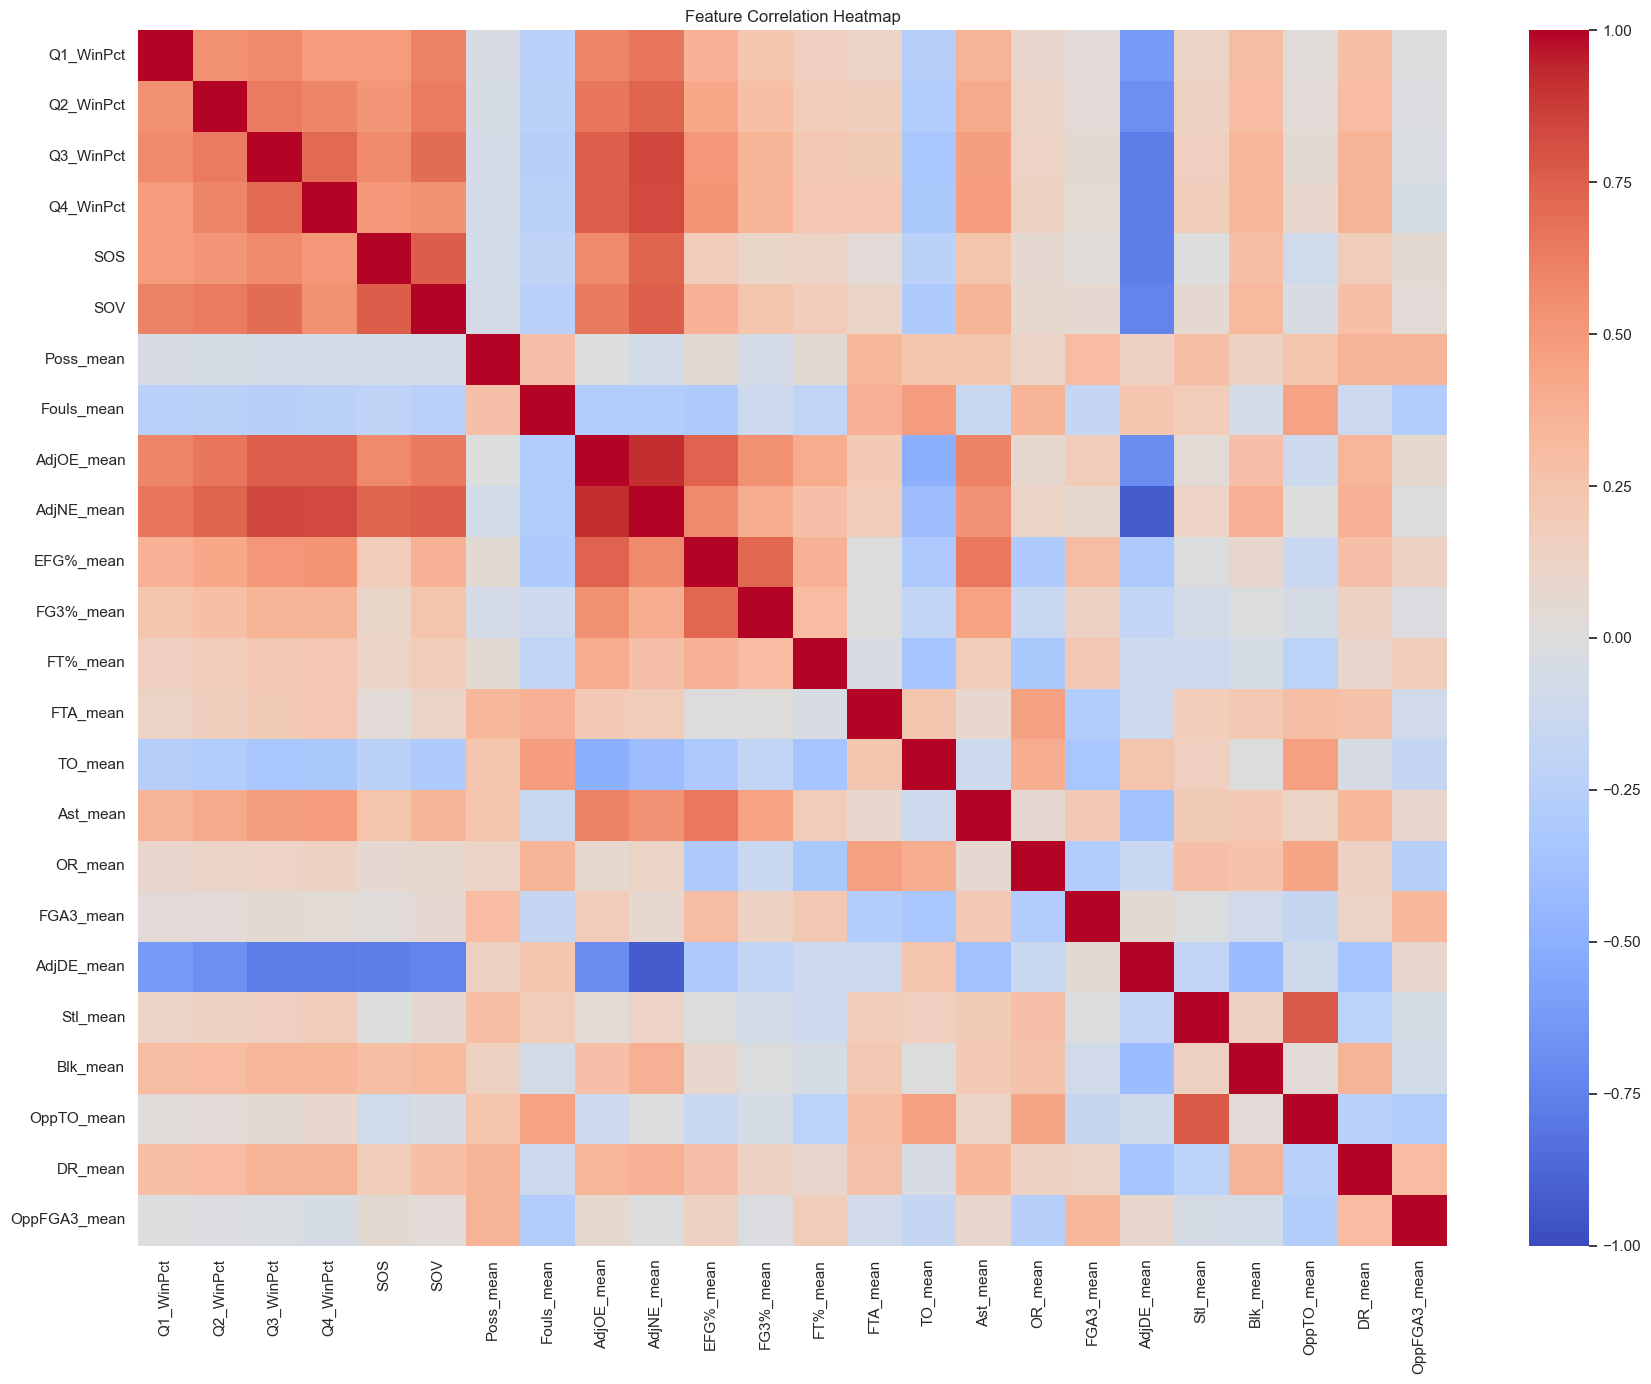

,Seed,ExitRoundNum
AdjNE_mean,-0.863,0.510
Q1_WinPct,-0.756,0.458
AdjOE_mean,-0.729,0.452
SOV,-0.790,0.429
SOS,-0.762,0.390
Q2_WinPct,-0.626,0.360
Q3_WinPct,-0.649,0.358
Q4_WinPct,-0.590,0.293
Ast_mean,-0.367,0.229
Blk_mean,-0.339,0.229


In [50]:
corr_df = eda_df[ALL_FEATURES].corr()

plt.figure(figsize=(18, 14))
sns.heatmap(corr_df, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
exit_round_map = {
    "Play In": 1,
    "First Round": 1,
    "Second Round": 2,
    "Sweet Sixteen": 3,
    "Elite Eight": 4,
    "Final Four": 5,
    "Championship": 6,
    "Champion": 7,
}

seeded_eda_df["ExitRoundNum"] = seeded_eda_df["ExitRound"].map(exit_round_map)

seed_exit_corr = (
    seeded_eda_df[ALL_FEATURES + ["Seed", "ExitRoundNum"]]
    .corr()
    .loc[ALL_FEATURES, ["Seed", "ExitRoundNum"]]
    .sort_values("ExitRoundNum", ascending=False)
    .round(3)
)

display(seed_exit_corr)

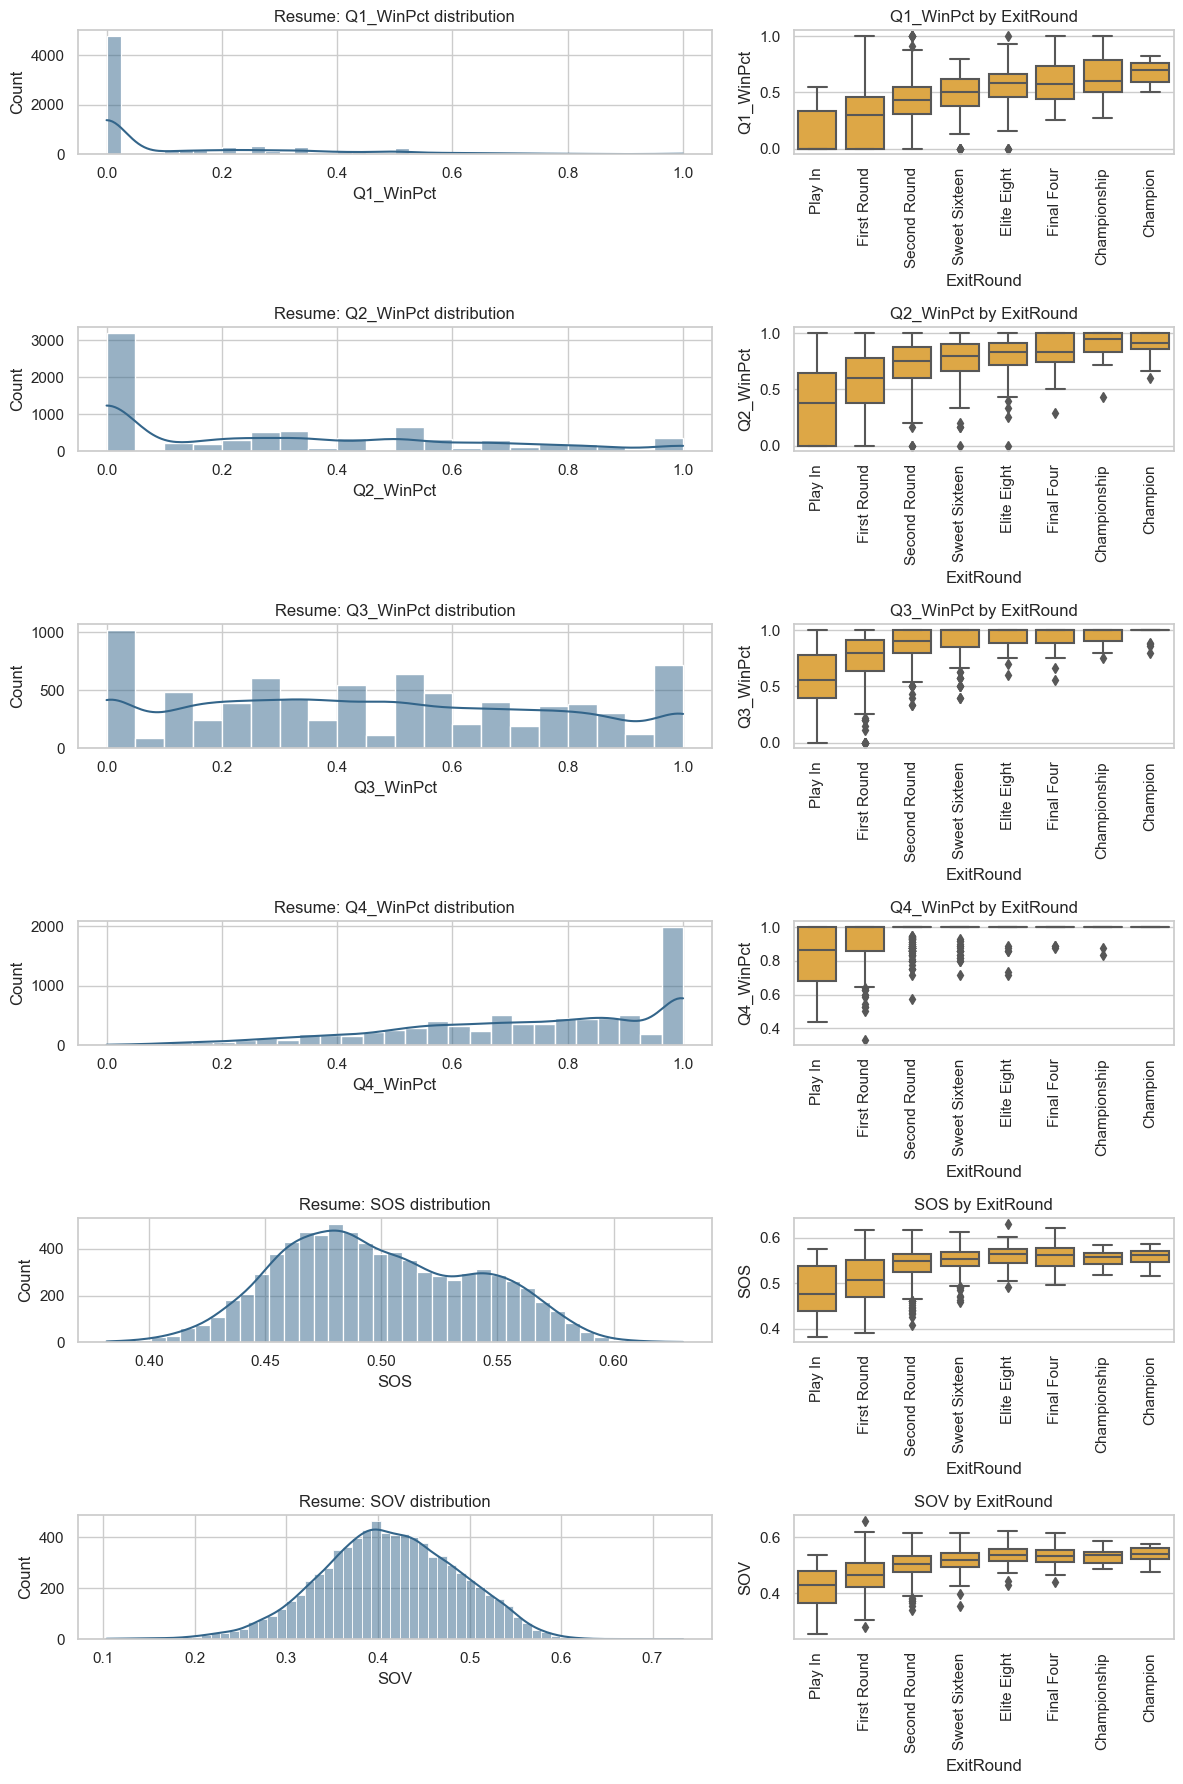

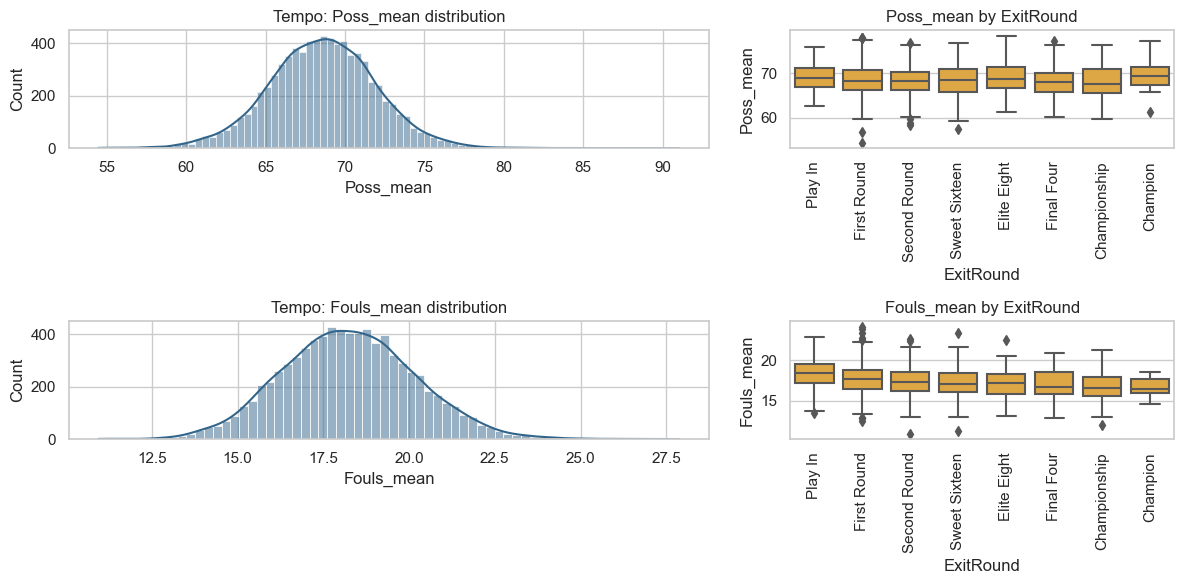

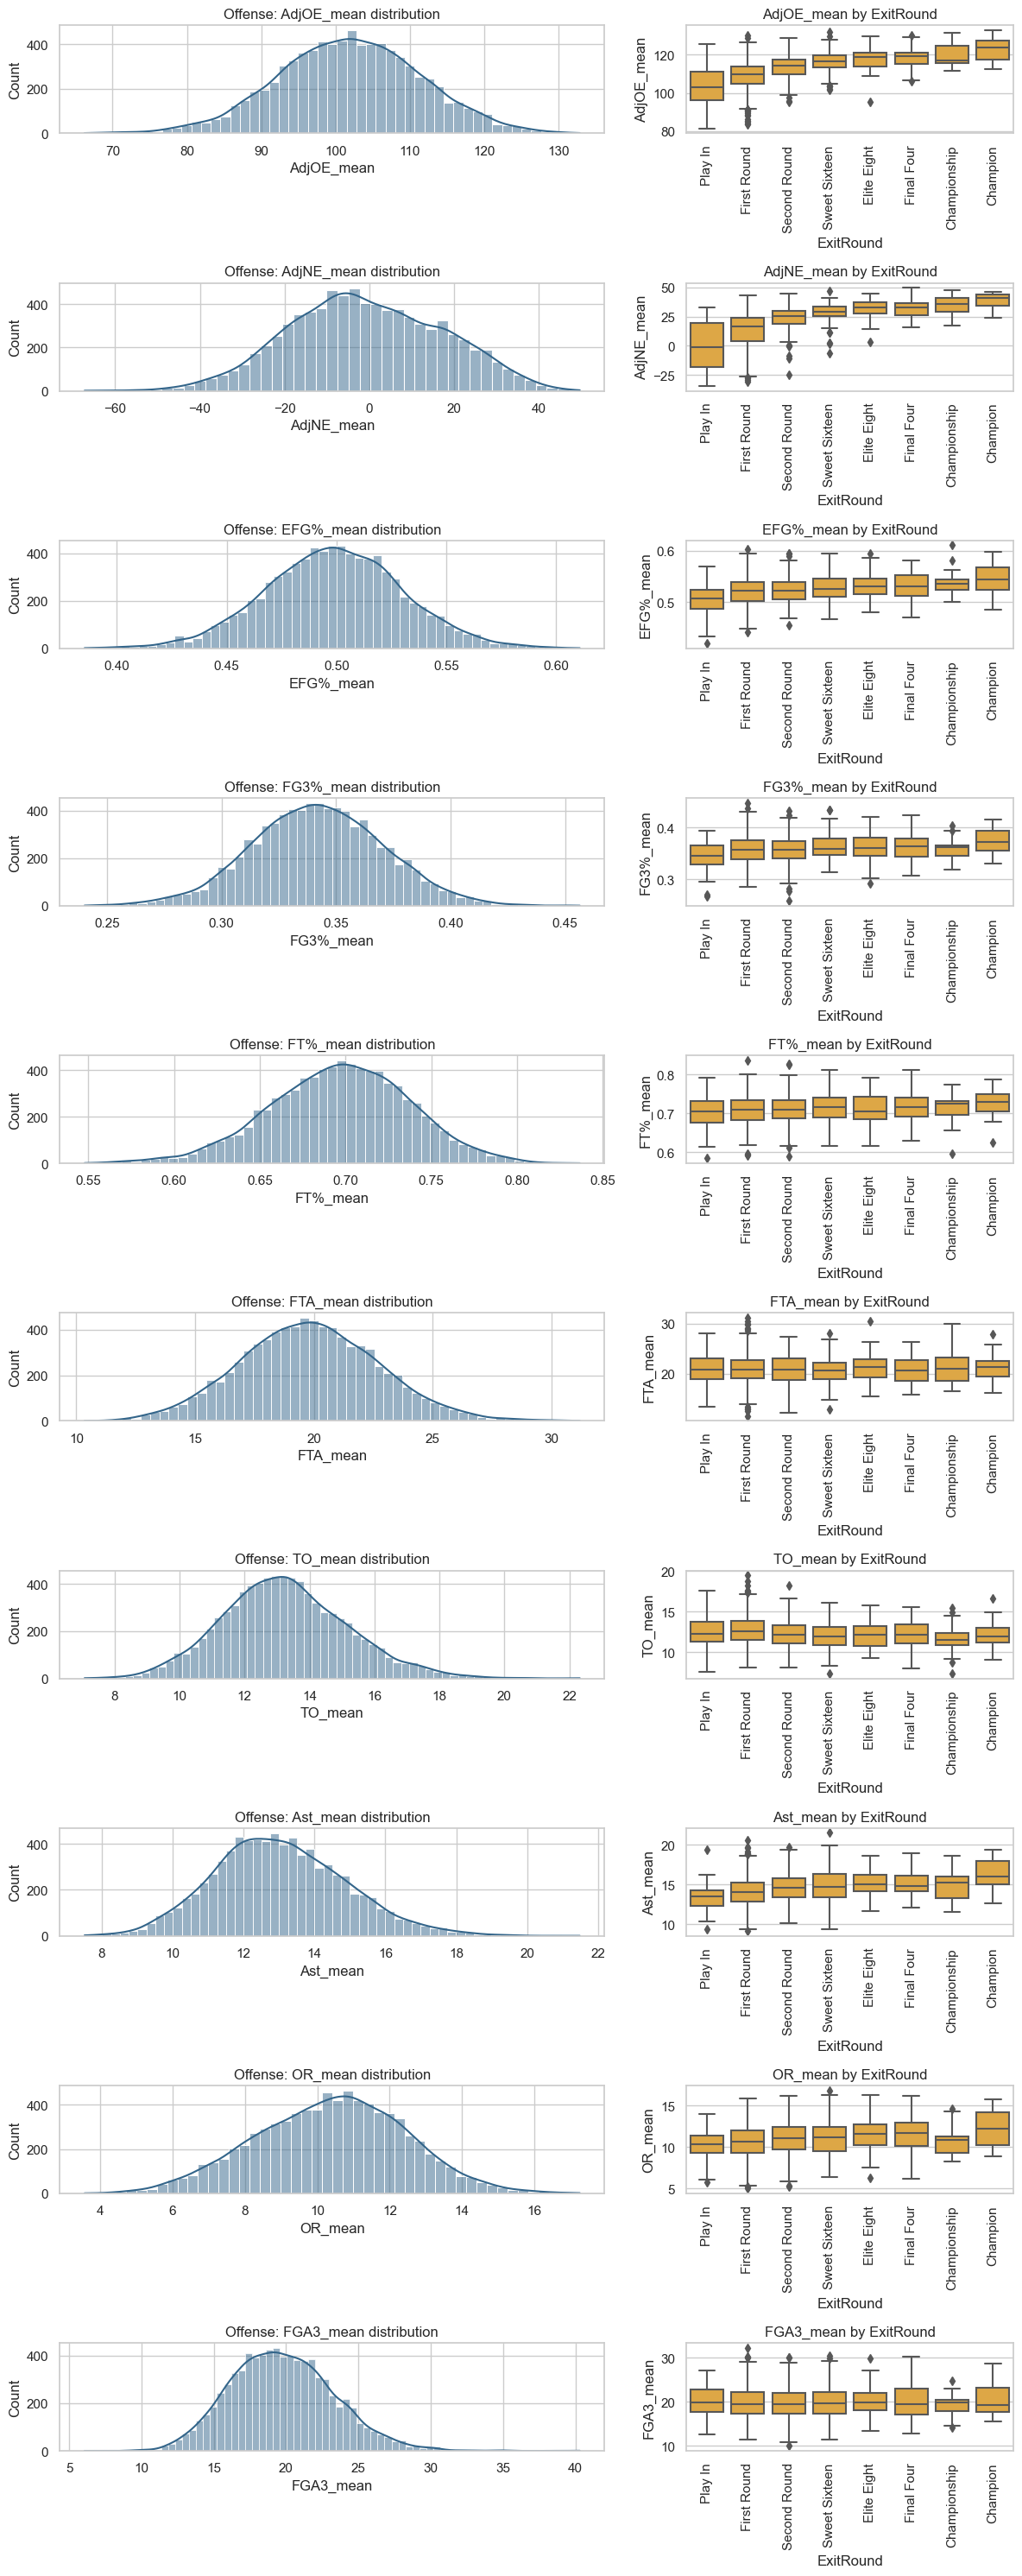

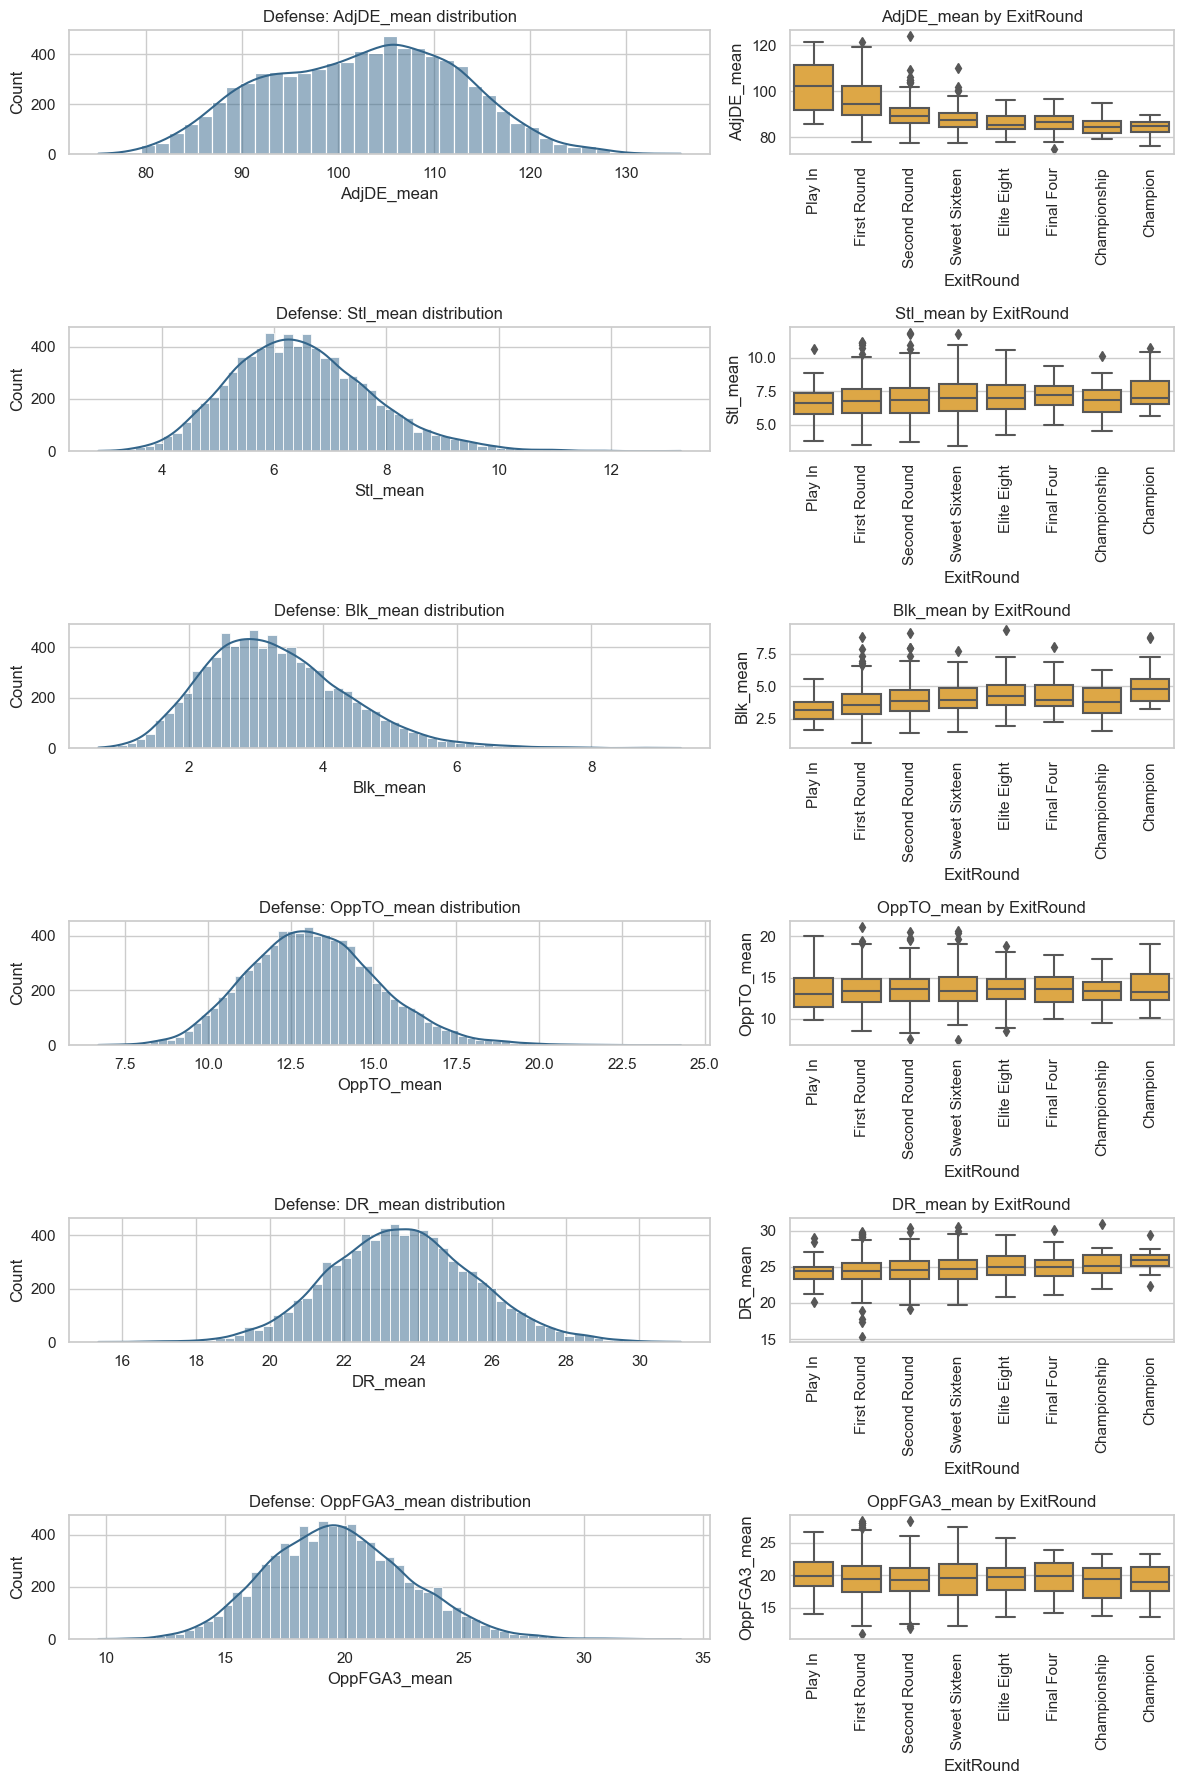

In [25]:
exit_round_order = [
    "Play In",
    "First Round",
    "Second Round",
    "Sweet Sixteen",
    "Elite Eight",
    "Final Four",
    "Championship",
    "Champion",
]

for group_name, features in FEATURE_GROUPS.items():
    fig, axes = plt.subplots(
        nrows=len(features),
        ncols=2,
        figsize=(12, max(3 * len(features), 6)),
        gridspec_kw={"width_ratios": [2.5, 1.5]},
    )
    if len(features) == 1:
        axes = [axes]

    for row_axes, feature in zip(axes, features):
        sns.histplot(eda_df[feature].dropna(), kde=True, ax=row_axes[0], color="#33658A")
        row_axes[0].set_title(f"{group_name}: {feature} distribution")

        sns.boxplot(
            data=seeded_eda_df,
            x="ExitRound",
            y=feature,
            order=exit_round_order,
            ax=row_axes[1],
            color="#F6AE2D",
        )
        row_axes[1].tick_params(axis="x", labelrotation=90)
        row_axes[1].set_title(f"{feature} by ExitRound")

    plt.tight_layout()
    plt.show()

ExitTier,No tourney win,Round of 32,Sweet 16,Elite 8,Final Four+
Q1_WinPct,NaN,0.264337,0.422828,0.508538,0.619920
Q2_WinPct,NaN,0.545807,0.724991,0.777846,0.855485
Q3_WinPct,NaN,0.744879,0.877387,0.920608,0.946207
Q4_WinPct,NaN,0.912327,0.977075,0.985880,0.992740
SOS,NaN,0.508266,0.540796,0.553853,0.556565
SOV,NaN,0.460325,0.502266,0.522704,0.533831
Poss_mean,NaN,68.451212,68.168389,68.592898,68.397363
Fouls_mean,NaN,17.756281,17.435413,17.223049,16.811206
AdjOE_mean,NaN,108.845500,113.855637,117.022861,119.691794
AdjNE_mean,NaN,12.499514,23.986021,29.811428,34.197520


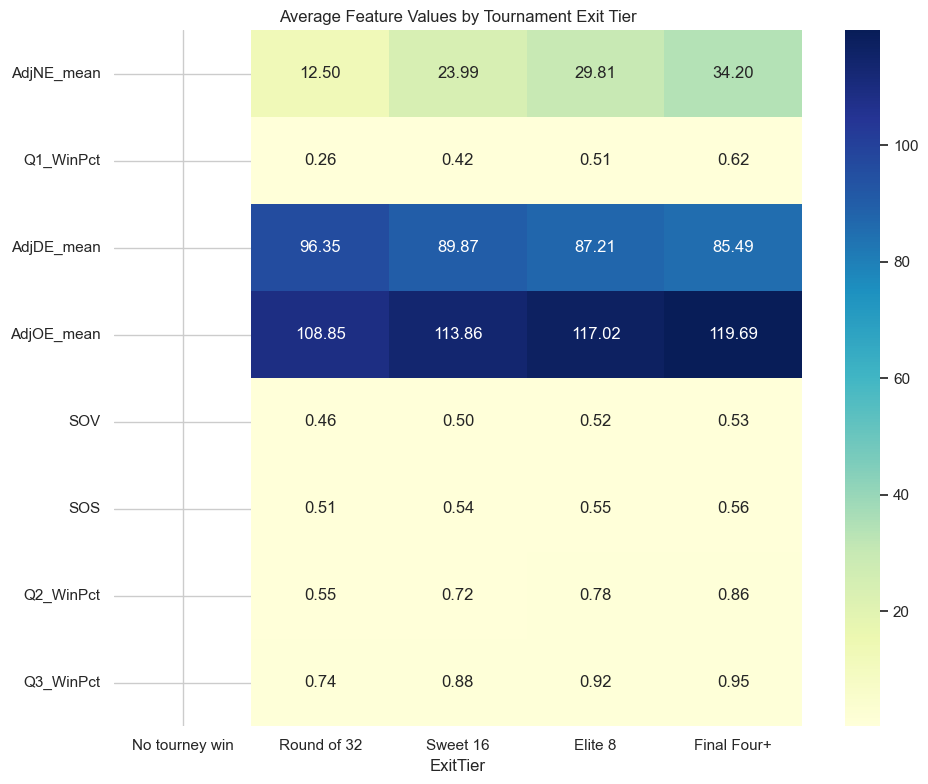

In [51]:
seed_bins = [-0.5, 0.5, 1.5, 2.5, 4.5, 6.5]
seed_labels = ["No tourney win", "Round of 32", "Sweet 16", "Elite 8", "Final Four+"]

seeded_eda_df = seeded_eda_df.assign(
    ExitTier=pd.cut(
        seeded_eda_df["ExitRoundNum"].clip(lower=0, upper=6),
        bins=seed_bins,
        labels=seed_labels,
    )
)

group_means = (
    seeded_eda_df.groupby("ExitTier", observed=False)[ALL_FEATURES]
    .mean()
    .T
)

display(group_means)

top_signal_features = seed_exit_corr["ExitRoundNum"].abs().sort_values(ascending=False).head(8).index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    group_means.loc[top_signal_features],
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
)
plt.title("Average Feature Values by Tournament Exit Tier")
plt.tight_layout()
plt.show()

## Wireframe: Tournament Pick Support
The goal is not just to show a team's raw feature values. It is to answer a pick question like:

> If I pick Kansas to reach the Final Four, does Kansas look normal or unusual relative to past Final Four teams on `AdjNE_mean` and related metrics?

> Does Kansas also look like a typical strong tournament team relative to the full historical field?

> Which rounds does a Kansas-like profile usually reach?

> Recommended layout

```text
┌──────────────────────────────────────────────────────────────────────────────┐
│ Team Pick Profile                                                           │
│ Team: Kansas | Seed: 4 | Chosen round: Final Four | Feature: AdjNE_mean    │
│ Expected advancement: Sweet 16 32% | Elite Eight 24% | Final Four 18% ...  │
└──────────────────────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────┬──────────────────────────────────────┐
│ 1. Advancement Distribution          │ 2. Feature Benchmark Distribution    │
│ Bar or lollipop chart                │ Violin / KDE / boxen plot            │
│ x = round reached                    │ x = feature value                    │
│ y = probability / comparable share   │ y = cohort: All / Final Four / etc.  │
│ highlight this team's expected path  │ vertical line = current team value   │
└──────────────────────────────────────┴──────────────────────────────────────┘

┌──────────────────────────────────────┬──────────────────────────────────────┐
│ 3. Similar-Team Panel                │ 4. Feature Radar / Z-score Strip     │
│ nearest historical teams             │ show where team sits vs cohorts      │
│ show actual exit round outcomes      │ highlight top signal features        │
│ add count of comps by exit round     │ use percentile or z-score labels     │
└──────────────────────────────────────┴──────────────────────────────────────┘

┌──────────────────────────────────────────────────────────────────────────────┐
│ 5. Explanation Table                                                         │
│ Feature      Team   Final Four Med   All-Tourney Med   FF Percentile        │
│ AdjNE_mean   38.4   31.1             18.5              73rd                 │
│ SOS          0.61   0.58             0.51              68th                 │
│ ...                                                                        │
└──────────────────────────────────────────────────────────────────────────────┘
```

### How this EDA powers the wireframe
- `seed_exit_corr` identifies which features matter most for advancement and should be defaulted in the UI.
- The grouped boxplots show the historical shape of each feature by exit round and can become the feature benchmark panel.
- `group_means` supports concise summary cards like `Final Four teams average +31 AdjNE` or `Champion teams usually have lower AdjDE`.
- The full correlation heatmap helps avoid overloading the interface with redundant metrics that move together.

### Recommended user flow
1. Select a 2026 tournament team.
2. Pick a target round like `Sweet Sixteen`, `Elite Eight`, or `Final Four`.
3. Start with the 5 to 8 highest-signal features from `seed_exit_corr`.
4. Show whether the team is typical, strong, or an outlier against that round's historical cohort.
5. Let the user drill down from overall advancement distribution into one feature at a time.

In [52]:
teams_df = pd.read_csv("../data/kaggle-v2/MTeams.csv")[["TeamID", "TeamName"]]

historical_tourney_df = (
    seeded_eda_df[["TeamID", "Season", "Seed", "ExitRound", "ExitRoundNum"] + ALL_FEATURES]
    .merge(teams_df, on="TeamID", how="left")
)

current_tourney_df = (
    cur_ts_df.loc[~cur_ts_df["Seed"].isna(), ["TeamID", "Season", "Seed"] + ALL_FEATURES]
    .merge(teams_df, on="TeamID", how="left")
    .sort_values(["Seed", "TeamName"])
)

def build_feature_benchmark(team_name, feature="AdjNE_mean", season=2026):
    team_row = current_tourney_df.loc[
        (current_tourney_df["TeamName"] == team_name) & (current_tourney_df["Season"] == season)
    ]
    if team_row.empty:
        raise ValueError(f"No current tournament team found for {team_name!r} in {season}.")

    team_value = float(team_row.iloc[0][feature])
    history = historical_tourney_df[["TeamName", "Season", "Seed", "ExitRound", "ExitRoundNum", feature]].dropna()

    cohort_summary = (
        history.groupby(["ExitRound", "ExitRoundNum"], as_index=False)[feature]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
        .sort_values("ExitRoundNum")
    )
    cohort_summary["team_percentile"] = cohort_summary["ExitRound"].map(
        history.groupby("ExitRound")[feature].apply(lambda values: round((values <= team_value).mean(), 3))
    )

    benchmark_dist = pd.concat(
        [
            history[[feature, "ExitRound"]].rename(columns={"ExitRound": "cohort"}),
            history[[feature]].assign(cohort="All Historical Tournament Teams"),
        ],
        ignore_index=True,
    )

    return {
        "team_row": team_row.iloc[0],
        "team_value": team_value,
        "cohort_summary": cohort_summary,
        "benchmark_dist": benchmark_dist,
    }

example_benchmark = build_feature_benchmark("Kansas", feature="AdjDE_mean")
display(example_benchmark["cohort_summary"])

,ExitRound,ExitRoundNum,count,mean,median,std,team_percentile
4,First Round,1.0,703,95.791461,94.297306,7.988954,0.070
5,Play In,1.0,64,102.437096,102.153122,11.084118,0.000
6,Second Round,2.0,352,89.869616,89.039180,5.479559,0.210
7,Sweet Sixteen,3.0,176,87.680187,87.575286,4.675769,0.312
2,Elite Eight,4.0,88,86.273924,85.301661,4.243965,0.534
3,Final Four,5.0,44,86.401350,86.373043,4.580265,0.455
1,Championship,6.0,22,84.743866,84.235426,3.950883,0.591
0,Champion,7.0,22,84.430532,85.041491,3.365784,0.591


# 2025 Similarity

In [ ]:
from typing import Dict, List, Tuple
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
def get_historical_similarity(df, num_teams:int = 3, precision:int = 5) -> Dict[Tuple[int, int], List[Tuple[Tuple[int, int], float]]]:
    """Using resume and stats data
    calculate the similarity between teams
    and return the top n most similar teams
    :param df { DataFrame }: The dataframe containing the team data
    :param num_teams { int }: The number of similar teams to return
    :return { Dict[Tuple[int, int], List[Tuple[Tuple[int, int], float]]] }: A dictionary of (team id, season)
        mapped to and their most similar (team id, season) with similarity score
    """
    # Build Resume Similarity
    resume_cols = RESUME_FEATURES
    resume_df = df[resume_cols]
    resume_df.fillna(0, inplace=True)
    resume_scaler = MinMaxScaler()
    resume_df = resume_scaler.fit_transform(resume_df)
    resume_similarity = cosine_similarity(resume_df)

    # Build Stat Similarity
    stat_cols = OFF_FEATURES + DEF_FEATURES + TEMPO_FEATURES
    stat_df = df[stat_cols]
    stat_scaler = MinMaxScaler()
    stat_df = stat_scaler.fit_transform(stat_df)
    stat_similarity = cosine_similarity(stat_df)

    # Average the two similarities
    avg_similarity = (resume_similarity + stat_similarity) / 2

    similar_teams = {}
    for i in range(len(avg_similarity)):
        avg_similarity[i][i] = 0

        arr = avg_similarity[i]
        # Get the indices of the most similar n values
        top_n_indices = arr.argsort()[-num_teams:][::-1]

        # Set the most similar teams
        similar_teams[(int(df.iloc[i]['TeamID']), int(df.iloc[i]['Season']))] = [(
            int(df.iloc[j]['TeamID']), int(df.iloc[j]['Season']),
            round(avg_similarity[i][j], precision),
            round(resume_similarity[i][j], precision),
            round(stat_similarity[i][j], precision)
        ) for j in top_n_indices]
    return similar_teams

### 2026 Similar Team Recommendation
For the product use case, a targeted `current team -> historical tournament teams` lookup is a better fit than the older all-pairs dictionary.

Why:
- the UI only needs one selected 2026 team at a time
- we want only historical tournament teams as comparables
- we want enriched context like `ExitRound` and `lost_to`, not just a raw similarity score
- a light seed prior is helpful so a 1-seed is not primarily compared with 12-seeds unless the profile is unusually close

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

SIMILARITY_FEATURES = ALL_FEATURES
SIMILARITY_DEFAULTS = historical_tourney_df[SIMILARITY_FEATURES].median(numeric_only=True)

def get_tournament_loss_context(team_id, season, tournament_games=tourney_df, teams_lookup=teams_df):
    loss = tournament_games.loc[
        (tournament_games["Season"] == season) & (tournament_games["LTeamID"] == team_id)
    ].sort_values("DayNum")

    if loss.empty:
        return pd.Series({
            "lost_to_team_id": None,
            "lost_to": None,
            "loss_score": None,
            "loss_day_num": None,
        })

    loss_row = loss.iloc[0]
    opponent_name = teams_lookup.loc[
        teams_lookup["TeamID"] == loss_row["WTeamID"],
        "TeamName",
    ].iloc[0]

    return pd.Series({
        "lost_to_team_id": int(loss_row["WTeamID"]),
        "lost_to": opponent_name,
        "loss_score": f"{int(loss_row['LScore'])}-{int(loss_row['WScore'])}",
        "loss_day_num": int(loss_row["DayNum"]),
    })

def find_similar_tourney_teams(
    team_name,
    top_n=5,
    feature_cols=SIMILARITY_FEATURES,
    historical_start=2003,
    historical_end=2025,
    seed_window=2,
    seed_weight=0.15,
    historical_df=historical_tourney_df,
    current_df=current_tourney_df,
):
    current_match = current_df.loc[current_df["TeamName"] == team_name].copy()
    if current_match.empty:
        raise ValueError(f"No current tournament team found for {team_name!r}.")

    current_row = current_match.iloc[0].copy()
    current_seed = current_row.get("Seed")

    candidates = historical_df.loc[
        historical_df["Season"].between(historical_start, historical_end),
        ["TeamID", "TeamName", "Season", "Seed", "ExitRound", "ExitRoundNum"] + feature_cols,
    ].copy()

    candidates[feature_cols] = candidates[feature_cols].fillna(0)
    current_vector = current_row[feature_cols].fillna(0)

    if pd.notna(current_seed) and seed_window is not None:
        seed_filtered = candidates.loc[candidates["Seed"].between(int(current_seed) - seed_window, int(current_seed) + seed_window)].copy()
        if len(seed_filtered) >= top_n:
            candidates = seed_filtered

    scaler = StandardScaler()
    candidate_matrix    = scaler.fit_transform(candidates[feature_cols])
    current_matrix      = scaler.transform(pd.DataFrame([current_vector], columns=feature_cols))
    feature_similarity  = cosine_similarity(current_matrix, candidate_matrix).ravel()

    if pd.notna(current_seed):
        seed_distance = (candidates["Seed"] - current_seed).abs().fillna(16)
        max_seed_distance = max(float(seed_distance.max()), 1.0)
        seed_score = 1 - (seed_distance / max_seed_distance)
        combined_similarity = ((1 - seed_weight) * feature_similarity) + (seed_weight * seed_score.to_numpy())
    else:
        combined_similarity = feature_similarity

    neighbors = candidates.assign(
        similarity=combined_similarity,
        feature_similarity=feature_similarity,
    ).sort_values("similarity", ascending=False).head(top_n).reset_index(drop=True)

    loss_context = neighbors.apply(
        lambda row: get_tournament_loss_context(int(row["TeamID"]), int(row["Season"])),
        axis=1,
    ).reset_index(drop=True)

    return pd.concat([neighbors, loss_context], axis=1)[
        [
            "TeamName",
            "Season",
            "Seed",
            "similarity",
            "feature_similarity",
            "ExitRound",
            "lost_to",
            "loss_score",
        ]
    ].round({"similarity": 3, "feature_similarity": 3})

display(find_similar_tourney_teams("Kansas", top_n=5))

,TeamName,Season,Seed,similarity,feature_similarity,ExitRound,lost_to,loss_score
0,Arizona,2025,4.0,0.704,0.651,Sweet Sixteen,Duke,93-100
1,Clemson,2018,5.0,0.689,0.723,Sweet Sixteen,Kansas,76-80
2,Duke,2023,5.0,0.662,0.691,Second Round,Tennessee,52-65
3,Kansas,2019,4.0,0.661,0.601,Second Round,Auburn,75-89
4,Oregon,2025,5.0,0.653,0.680,Second Round,Arizona,83-87


# Team Insights

> Next step: predict a seeded team's tournament exit-round distribution from its team profile, then turn that into floor, ceiling, and seed-relative expectations.

A probabilistic multi-class model is a better fit than a plain regression here because it gives us the full exit-round distribution for each team:
- expected round reached
- floor and ceiling from the probability distribution
- over/under-performance relative to historical teams with the same seed
- within-region comparisons for bracket decision support

> Use case

> If I pick a team to make the Elite Eight or Final Four, how aggressive is that pick relative to its seed, and how does that team compare to the rest of its region?

,value
holdout_season,2025.000
team_count,68.000
accuracy,0.544
top_2_accuracy,0.735
log_loss,0.981


,Region,region_rank,TeamName,Seed,expected_exit_round,floor_round,ceiling_round,seed_expected_round,seed_delta,p_sweet16_plus,p_elite8_plus,p_final4_plus
0,W,1,Duke,1,4.420,Sweet Sixteen,Championship,4.295,0.125,0.794,0.664,0.560
1,W,2,Michigan St,3,3.493,Round of 32,Final Four,2.977,0.516,0.568,0.362,0.260
2,W,3,Connecticut,2,3.012,Round of 32,Elite Eight,3.261,-0.249,0.580,0.327,0.147
3,W,4,Kansas,4,2.759,Round of 32,Sweet Sixteen,2.568,0.191,0.539,0.224,0.062
4,W,5,Louisville,6,2.112,Round of 64,Sweet Sixteen,1.841,0.271,0.291,0.119,0.084
...,...,...,...,...,...,...,...,...,...,...,...,...
63,Z,13,High Point,12,1.364,Round of 64,Round of 32,1.489,-0.125,0.021,0.009,0.002
64,Z,14,Hawaii,13,1.149,Round of 64,Round of 64,1.236,-0.087,0.018,0.002,0.001
65,Z,15,Queens NC,15,1.121,Round of 64,Round of 64,1.136,-0.015,0.018,0.004,0.001
66,Z,16,Kennesaw,14,1.069,Round of 64,Round of 64,1.112,-0.043,0.010,0.004,0.001


,TeamName,Region,Seed,expected_exit_round,most_likely_round,floor_round,ceiling_round,seed_expected_round,seed_delta,p_sweet16_plus,p_elite8_plus,p_final4_plus,p_title_game_plus
14,Kansas,W,4,2.759,Round of 32,Round of 32,Sweet Sixteen,2.568,0.191,0.539,0.224,0.062,0.041


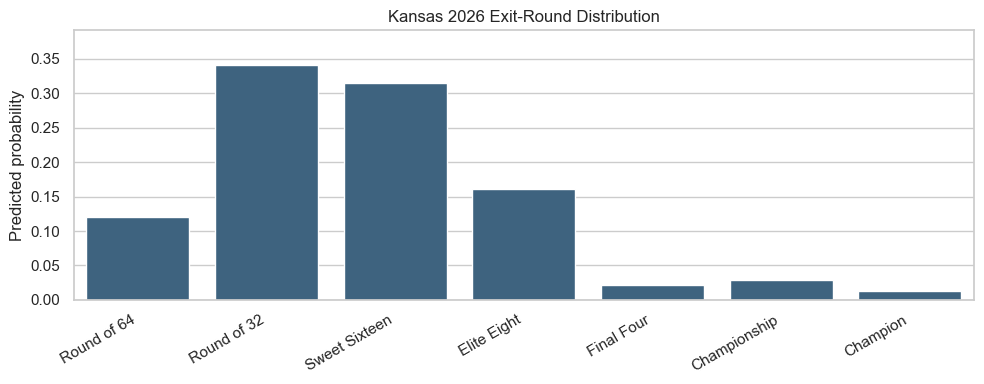

In [53]:
from sklearn.metrics import accuracy_score, log_loss, top_k_accuracy_score

EXIT_ROUND_LABELS_BY_NUM = {
    1: "Round of 64",
    2: "Round of 32",
    3: "Sweet Sixteen",
    4: "Elite Eight",
    5: "Final Four",
    6: "Championship",
    7: "Champion",
}
EXIT_PROBABILITY_COLUMNS = {
    1: "p_round64",
    2: "p_round32",
    3: "p_sweet16",
    4: "p_elite8",
    5: "p_final4",
    6: "p_championship",
    7: "p_champion",
}
EXIT_MODEL_FEATURES = ["Seed"] + ALL_FEATURES

def exit_round_quantile(prob_vector, quantile):
    cumulative = np.cumsum(prob_vector)
    return int(np.searchsorted(cumulative, quantile) + 1)

def exit_round_label(round_num):
    return EXIT_ROUND_LABELS_BY_NUM[int(round_num)]

exit_model_df = prev_ts_df.loc[
    ~prev_ts_df["Seed"].isna(),
    ["TeamID", "Season", "Seed", "ExitRound"] + ALL_FEATURES,
].copy()
exit_model_df["ExitRoundNum"] = exit_model_df["ExitRound"].map(exit_round_map)
exit_model_df = exit_model_df.dropna(subset=["ExitRoundNum"]).copy()
exit_model_df[EXIT_MODEL_FEATURES] = exit_model_df[EXIT_MODEL_FEATURES].fillna(0)
exit_model_df["ExitRoundNum"] = exit_model_df["ExitRoundNum"].astype(int)

train_exit_df = exit_model_df.loc[exit_model_df["Season"] < 2025].copy()
valid_exit_df = exit_model_df.loc[exit_model_df["Season"] == 2025].copy()

exit_round_model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=7,
    eval_metric="mlogloss",
    n_estimators=350,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.8,
    min_child_weight=2,
    reg_lambda=1.0,
    random_state=42,
    use_label_encoder=False,
 )

X_exit_train = train_exit_df[EXIT_MODEL_FEATURES]
y_exit_train = train_exit_df["ExitRoundNum"] - 1
X_exit_valid = valid_exit_df[EXIT_MODEL_FEATURES]
y_exit_valid = valid_exit_df["ExitRoundNum"] - 1

_ = exit_round_model.fit(X_exit_train, y_exit_train)

valid_probs = exit_round_model.predict_proba(X_exit_valid)
valid_pred_num = valid_probs.argmax(axis=1) + 1
valid_metrics = pd.Series(
    {
        "holdout_season": 2025,
        "team_count": len(valid_exit_df),
        "accuracy": round(accuracy_score(valid_exit_df["ExitRoundNum"], valid_pred_num), 3),
        "top_2_accuracy": round(
            top_k_accuracy_score(y_exit_valid, valid_probs, k=2, labels=np.arange(7)),
            3,
        ),
        "log_loss": round(log_loss(y_exit_valid, valid_probs, labels=np.arange(7)), 3),
    }
)
display(valid_metrics.to_frame("value"))

seed_distribution = (
    exit_model_df.groupby(["Seed", "ExitRoundNum"]).size().unstack(fill_value=0)
    .reindex(columns=range(1, 8), fill_value=0)
)
seed_distribution = seed_distribution.div(seed_distribution.sum(axis=1), axis=0)

seed_baseline_df = pd.DataFrame(
    {
        "Seed": seed_distribution.index.astype(int),
        "seed_expected_round": [
            float(np.dot(row.to_numpy(), np.arange(1, 8)))
            for _, row in seed_distribution.iterrows()
        ],
        "seed_floor_round": [
            exit_round_quantile(row.to_numpy(), 0.25)
            for _, row in seed_distribution.iterrows()
        ],
        "seed_ceiling_round": [
            exit_round_quantile(row.to_numpy(), 0.75)
            for _, row in seed_distribution.iterrows()
        ],
        "historical_seed_count": exit_model_df.groupby("Seed").size().reindex(seed_distribution.index).astype(int).values,
    }
).round(3)

seed_file_df = pd.read_csv("../data/kaggle-v2/MNCAATourneySeeds.csv")
seed_file_df = seed_file_df.loc[seed_file_df["Season"] == 2026, ["TeamID", "Seed"]].copy()
seed_file_df = seed_file_df.rename(columns={"Seed": "SeedLabel"})
seed_file_df["Region"] = seed_file_df["SeedLabel"].str[0]
seed_file_df["SeedNum"] = seed_file_df["SeedLabel"].str[1:3].astype(int)

current_exit_df = (
    current_tourney_df.drop(columns=["Seed"])
    .merge(seed_file_df[["TeamID", "SeedLabel", "SeedNum", "Region"]], on="TeamID", how="left")
    .rename(columns={"SeedNum": "Seed"})
)
current_exit_df[EXIT_MODEL_FEATURES] = current_exit_df[EXIT_MODEL_FEATURES].fillna(0)

current_probs = exit_round_model.predict_proba(current_exit_df[EXIT_MODEL_FEATURES])
probability_df = pd.DataFrame(
    current_probs,
    columns=[EXIT_PROBABILITY_COLUMNS[idx] for idx in range(1, 8)],
)

current_exit_summary = pd.concat([current_exit_df.reset_index(drop=True), probability_df], axis=1)
current_exit_summary["expected_exit_round"] = [
    float(np.dot(prob_vector, np.arange(1, 8)))
    for prob_vector in current_probs
]
current_exit_summary["most_likely_round_num"] = current_probs.argmax(axis=1) + 1
current_exit_summary["floor_round_num"] = [
    exit_round_quantile(prob_vector, 0.25)
    for prob_vector in current_probs
]
current_exit_summary["ceiling_round_num"] = [
    exit_round_quantile(prob_vector, 0.75)
    for prob_vector in current_probs
]
current_exit_summary["p_sweet16_plus"] = current_probs[:, 2:].sum(axis=1)
current_exit_summary["p_elite8_plus"] = current_probs[:, 3:].sum(axis=1)
current_exit_summary["p_final4_plus"] = current_probs[:, 4:].sum(axis=1)
current_exit_summary["p_title_game_plus"] = current_probs[:, 5:].sum(axis=1)

current_exit_summary = current_exit_summary.merge(seed_baseline_df, on="Seed", how="left")
current_exit_summary["seed_delta"] = current_exit_summary["expected_exit_round"] - current_exit_summary["seed_expected_round"]
current_exit_summary["region_rank"] = (
    current_exit_summary.groupby("Region")["expected_exit_round"]
    .rank(ascending=False, method="dense")
    .astype(int)
)
current_exit_summary["most_likely_round"] = current_exit_summary["most_likely_round_num"].map(exit_round_label)
current_exit_summary["floor_round"] = current_exit_summary["floor_round_num"].map(exit_round_label)
current_exit_summary["ceiling_round"] = current_exit_summary["ceiling_round_num"].map(exit_round_label)

region_board = current_exit_summary[
    [
        "Region",
        "region_rank",
        "TeamName",
        "Seed",
        "expected_exit_round",
        "floor_round",
        "ceiling_round",
        "seed_expected_round",
        "seed_delta",
        "p_sweet16_plus",
        "p_elite8_plus",
        "p_final4_plus",
    ]
]
region_board = region_board.sort_values(["Region", "region_rank", "Seed", "TeamName"]).reset_index(drop=True)
display(region_board.round(3))

def show_team_exit_profile(team_name):
    team_rows = current_exit_summary.loc[current_exit_summary["TeamName"] == team_name].copy()
    if team_rows.empty:
        raise ValueError(f"No current 2026 tournament team found for {team_name!r}.")

    profile_cols = [
        "TeamName",
        "Region",
        "Seed",
        "expected_exit_round",
        "most_likely_round",
        "floor_round",
        "ceiling_round",
        "seed_expected_round",
        "seed_delta",
        "p_sweet16_plus",
        "p_elite8_plus",
        "p_final4_plus",
        "p_title_game_plus",
    ]
    display(team_rows[profile_cols].round(3))

    team_row = team_rows.iloc[0]
    plot_labels = [EXIT_ROUND_LABELS_BY_NUM[idx] for idx in range(1, 8)]
    plot_values = team_row[[EXIT_PROBABILITY_COLUMNS[idx] for idx in range(1, 8)]].to_numpy()

    plt.figure(figsize=(10, 4))
    sns.barplot(x=plot_labels, y=plot_values, color="#33658A")
    plt.title(f"{team_name} 2026 Exit-Round Distribution")
    plt.ylabel("Predicted probability")
    plt.xlabel("")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, max(plot_values.max() * 1.15, 0.1))
    plt.tight_layout()
    plt.show()

show_team_exit_profile("Kansas")

## TODO: Learn about Probability Calibration

The exit-round model ranks teams reasonably well, but the raw class probabilities can still be miscalibrated.

This section checks whether probabilities like `Sweet Sixteen+ = 0.40` behave like real 40% event rates, fits a lightweight one-vs-rest calibration layer on the 2025 holdout, and then compares calibrated versus uncalibrated 2026 team profiles.

,threshold,raw_brier,calibrated_brier,actual_rate,raw_mean_prob,calibrated_mean_prob
0,Sweet Sixteen+,0.1084,0.1178,0.2353,0.2657,0.2459
1,Elite Eight+,0.0406,0.0475,0.1176,0.1391,0.1289
2,Final Four+,0.0231,0.0283,0.0588,0.0728,0.0642


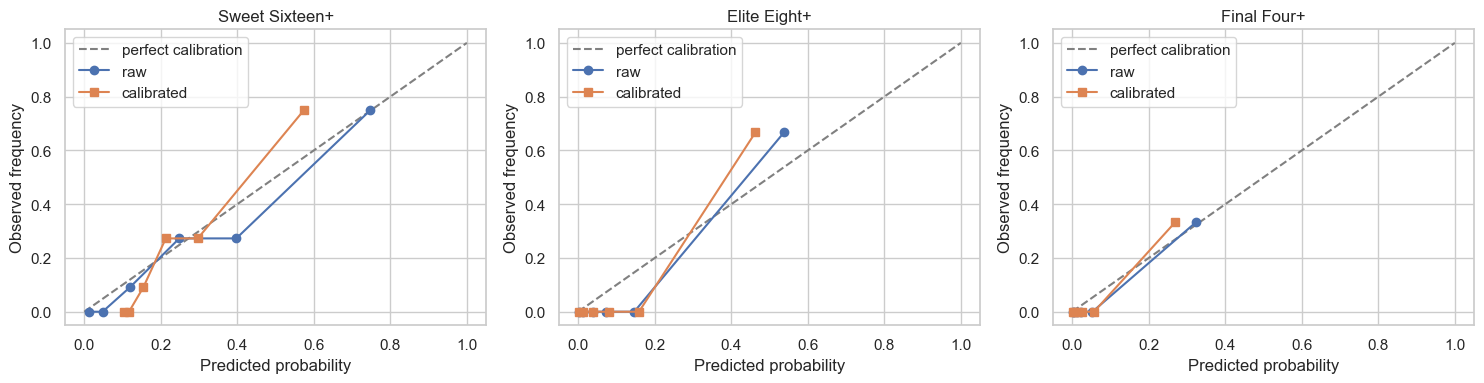

,TeamName,Region,Seed,expected_exit_round_raw,floor_round_raw,ceiling_round_raw,p_sweet16_plus_raw,p_elite8_plus_raw,p_final4_plus_raw,p_title_game_plus_raw,seed_delta_raw,expected_exit_round_calibrated,floor_round_calibrated,ceiling_round_calibrated,p_sweet16_plus_calibrated,p_elite8_plus_calibrated,p_final4_plus_calibrated,p_title_game_plus_calibrated,seed_delta_calibrated,expected_round_shift,final4_prob_shift
64,Lehigh,X,16,1.031,Round of 64,Round of 64,0.006,0.002,0.001,0.000,0.015,1.371,Round of 64,Round of 32,0.100,0.002,0.001,0.000,0.355,0.340,-0.0
59,Idaho,X,15,1.036,Round of 64,Round of 64,0.009,0.002,0.001,0.001,-0.100,1.373,Round of 64,Round of 32,0.101,0.002,0.001,0.000,0.237,0.336,-0.0
62,Howard,Y,16,1.042,Round of 64,Round of 64,0.008,0.003,0.001,0.000,0.026,1.375,Round of 64,Round of 32,0.101,0.002,0.001,0.000,0.359,0.333,-0.0
50,Cal Baptist,W,13,1.044,Round of 64,Round of 64,0.006,0.002,0.001,0.000,-0.192,1.374,Round of 64,Round of 32,0.101,0.002,0.001,0.000,0.138,0.331,-0.0
66,Siena,W,16,1.053,Round of 64,Round of 64,0.009,0.004,0.002,0.000,0.037,1.381,Round of 64,Round of 32,0.103,0.004,0.001,0.000,0.365,0.328,-0.0
65,Prairie View,X,16,1.061,Round of 64,Round of 64,0.009,0.005,0.001,0.001,0.045,1.385,Round of 64,Round of 32,0.103,0.004,0.001,0.001,0.369,0.325,-0.0
58,Furman,W,15,1.062,Round of 64,Round of 64,0.017,0.006,0.002,0.000,-0.074,1.385,Round of 64,Round of 32,0.104,0.005,0.002,0.000,0.249,0.323,-0.0
67,UMBC,Y,16,1.068,Round of 64,Round of 64,0.012,0.006,0.003,0.002,0.052,1.389,Round of 64,Round of 32,0.104,0.005,0.002,0.001,0.373,0.321,-0.0
56,Penn,X,14,1.065,Round of 64,Round of 64,0.012,0.003,0.002,0.000,-0.047,1.382,Round of 64,Round of 32,0.102,0.003,0.002,0.000,0.270,0.317,-0.0
54,Kennesaw,Z,14,1.069,Round of 64,Round of 64,0.010,0.004,0.001,0.001,-0.043,1.384,Round of 64,Round of 32,0.103,0.003,0.001,0.001,0.272,0.315,-0.0


,TeamName,Region,Seed,expected_exit_round_raw,floor_round_raw,ceiling_round_raw,p_sweet16_plus_raw,p_elite8_plus_raw,p_final4_plus_raw,p_title_game_plus_raw,seed_delta_raw,expected_exit_round_calibrated,floor_round_calibrated,ceiling_round_calibrated,p_sweet16_plus_calibrated,p_elite8_plus_calibrated,p_final4_plus_calibrated,p_title_game_plus_calibrated,seed_delta_calibrated,expected_round_shift,final4_prob_shift
14,Kansas,W,4,2.759,Round of 32,Sweet Sixteen,0.539,0.224,0.062,0.041,0.191,2.467,Round of 64,Elite Eight,0.397,0.25,0.07,0.046,-0.101,-0.292,0.007


In [43]:
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression

CALIBRATION_THRESHOLDS = {
    "Sweet Sixteen+": 3,
    "Elite Eight+": 4,
    "Final Four+": 5,
}

def normalize_probability_rows(prob_matrix):
    row_sums = prob_matrix.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    return prob_matrix / row_sums

def fit_class_probability_calibrators(prob_matrix, y_true_zero_based, min_examples=8):
    calibrators = []
    for class_idx in range(prob_matrix.shape[1]):
        y_binary = (y_true_zero_based == class_idx).astype(int)
        positive_count = int(y_binary.sum())
        negative_count = int(len(y_binary) - positive_count)

        if positive_count < min_examples or negative_count < min_examples:
            calibrators.append(None)
            continue

        calibrator = LogisticRegression(random_state=42)
        calibrator.fit(prob_matrix[:, [class_idx]], y_binary)
        calibrators.append(calibrator)
    return calibrators

def apply_class_probability_calibrators(prob_matrix, calibrators):
    calibrated = np.zeros_like(prob_matrix, dtype=float)
    for class_idx, calibrator in enumerate(calibrators):
        if calibrator is None:
            calibrated[:, class_idx] = prob_matrix[:, class_idx]
        else:
            calibrated[:, class_idx] = calibrator.predict_proba(prob_matrix[:, [class_idx]])[:, 1]
    return normalize_probability_rows(calibrated)

def probability_summary_from_matrix(prob_matrix):
    summary = pd.DataFrame(prob_matrix, columns=[EXIT_PROBABILITY_COLUMNS[idx] for idx in range(1, 8)])
    summary["expected_exit_round"] = [
        float(np.dot(prob_vector, np.arange(1, 8)))
        for prob_vector in prob_matrix
    ]
    summary["most_likely_round_num"] = prob_matrix.argmax(axis=1) + 1
    summary["floor_round_num"] = [
        exit_round_quantile(prob_vector, 0.25)
        for prob_vector in prob_matrix
    ]
    summary["ceiling_round_num"] = [
        exit_round_quantile(prob_vector, 0.75)
        for prob_vector in prob_matrix
    ]
    summary["p_sweet16_plus"] = prob_matrix[:, 2:].sum(axis=1)
    summary["p_elite8_plus"] = prob_matrix[:, 3:].sum(axis=1)
    summary["p_final4_plus"] = prob_matrix[:, 4:].sum(axis=1)
    summary["p_title_game_plus"] = prob_matrix[:, 5:].sum(axis=1)
    summary["most_likely_round"] = summary["most_likely_round_num"].map(exit_round_label)
    summary["floor_round"] = summary["floor_round_num"].map(exit_round_label)
    summary["ceiling_round"] = summary["ceiling_round_num"].map(exit_round_label)
    return summary

calibrators = fit_class_probability_calibrators(valid_probs, y_exit_valid.to_numpy())
calibrated_valid_probs = apply_class_probability_calibrators(valid_probs, calibrators)
calibrated_current_probs = apply_class_probability_calibrators(current_probs, calibrators)

calibration_metrics = []
for threshold_name, threshold_round in CALIBRATION_THRESHOLDS.items():
    y_binary = (valid_exit_df["ExitRoundNum"] >= threshold_round).astype(int).to_numpy()
    raw_scores = valid_probs[:, threshold_round - 1 :].sum(axis=1)
    calibrated_scores = calibrated_valid_probs[:, threshold_round - 1 :].sum(axis=1)

    calibration_metrics.append(
        {
            "threshold": threshold_name,
            "raw_brier": round(np.mean((raw_scores - y_binary) ** 2), 4),
            "calibrated_brier": round(np.mean((calibrated_scores - y_binary) ** 2), 4),
            "actual_rate": round(float(y_binary.mean()), 4),
            "raw_mean_prob": round(float(raw_scores.mean()), 4),
            "calibrated_mean_prob": round(float(calibrated_scores.mean()), 4),
        }
    )

calibration_metrics_df = pd.DataFrame(calibration_metrics)
display(calibration_metrics_df)

fig, axes = plt.subplots(1, len(CALIBRATION_THRESHOLDS), figsize=(5 * len(CALIBRATION_THRESHOLDS), 4))
if len(CALIBRATION_THRESHOLDS) == 1:
    axes = [axes]

for axis, (threshold_name, threshold_round) in zip(axes, CALIBRATION_THRESHOLDS.items()):
    y_binary = (valid_exit_df["ExitRoundNum"] >= threshold_round).astype(int).to_numpy()
    raw_scores = valid_probs[:, threshold_round - 1 :].sum(axis=1)
    calibrated_scores = calibrated_valid_probs[:, threshold_round - 1 :].sum(axis=1)

    raw_frac, raw_pred = calibration_curve(y_binary, raw_scores, n_bins=6, strategy="quantile")
    cal_frac, cal_pred = calibration_curve(y_binary, calibrated_scores, n_bins=6, strategy="quantile")

    axis.plot([0, 1], [0, 1], linestyle="--", color="gray", label="perfect calibration")
    axis.plot(raw_pred, raw_frac, marker="o", label="raw")
    axis.plot(cal_pred, cal_frac, marker="s", label="calibrated")
    axis.set_title(threshold_name)
    axis.set_xlabel("Predicted probability")
    axis.set_ylabel("Observed frequency")
    axis.legend()

plt.tight_layout()
plt.show()

calibrated_probability_summary = probability_summary_from_matrix(calibrated_current_probs)
calibrated_exit_summary = current_exit_df.reset_index(drop=True).copy()
calibrated_exit_summary = pd.concat([calibrated_exit_summary, calibrated_probability_summary], axis=1)
calibrated_exit_summary = calibrated_exit_summary.merge(seed_baseline_df, on="Seed", how="left")
calibrated_exit_summary["seed_delta"] = calibrated_exit_summary["expected_exit_round"] - calibrated_exit_summary["seed_expected_round"]
calibrated_exit_summary["region_rank"] = (
    calibrated_exit_summary.groupby("Region")["expected_exit_round"]
    .rank(ascending=False, method="dense")
    .astype(int)
 )

comparison_cols = [
    "TeamName",
    "Region",
    "Seed",
    "expected_exit_round",
    "floor_round",
    "ceiling_round",
    "p_sweet16_plus",
    "p_elite8_plus",
    "p_final4_plus",
    "p_title_game_plus",
    "seed_delta",
 ]

calibration_compare_df = current_exit_summary[comparison_cols].merge(
    calibrated_exit_summary[comparison_cols],
    on=["TeamName", "Region", "Seed"],
    suffixes=("_raw", "_calibrated"),
)
calibration_compare_df["expected_round_shift"] = (
    calibration_compare_df["expected_exit_round_calibrated"] - calibration_compare_df["expected_exit_round_raw"]
 )
calibration_compare_df["final4_prob_shift"] = (
    calibration_compare_df["p_final4_plus_calibrated"] - calibration_compare_df["p_final4_plus_raw"]
 )

display(
    calibration_compare_df.sort_values("expected_round_shift", ascending=False)
    .head(12)
    .round(3)
 )

display(
    calibration_compare_df.loc[calibration_compare_df["TeamName"] == "Kansas"]
    .round(3)
 )

In [41]:
display(region_board.sort_values("expected_exit_round", ascending=False).head(10).round(3))

,Region,region_rank,TeamName,Seed,expected_exit_round,floor_round,ceiling_round,seed_expected_round,seed_delta,p_sweet16_plus,p_elite8_plus,p_final4_plus
16,X,1,Florida,1,5.211,Elite Eight,Champion,4.295,0.916,0.862,0.793,0.579
33,Y,1,Michigan,1,4.581,Round of 32,Championship,4.295,0.286,0.702,0.621,0.574
0,W,1,Duke,1,4.420,Sweet Sixteen,Championship,4.295,0.125,0.794,0.664,0.560
51,Z,1,Arizona,1,4.113,Round of 32,Championship,4.295,-0.182,0.736,0.686,0.350
34,Y,2,Virginia,3,4.072,Round of 32,Final Four,2.977,1.095,0.739,0.572,0.450
17,X,2,Illinois,3,3.835,Round of 32,Final Four,2.977,0.858,0.705,0.580,0.359
18,X,3,Houston,2,3.778,Sweet Sixteen,Final Four,3.261,0.517,0.810,0.437,0.262
52,Z,2,Gonzaga,3,3.754,Round of 32,Championship,2.977,0.777,0.635,0.410,0.327
1,W,2,Michigan St,3,3.493,Round of 32,Final Four,2.977,0.516,0.568,0.362,0.260
19,X,4,Nebraska,4,3.081,Sweet Sixteen,Elite Eight,2.568,0.513,0.751,0.253,0.116


In [39]:
def show_region_board(region):
    region_rows = region_board.loc[region_board["Region"] == region].copy()
    display(region_rows.round(3))
    return region_rows

def show_seed_outliers(min_abs_delta=0.25):
    outlier_cols = [
        "TeamName",
        "Region",
        "Seed",
        "expected_exit_round",
        "seed_expected_round",
        "seed_delta",
        "floor_round",
        "ceiling_round",
        "p_sweet16_plus",
        "p_elite8_plus",
        "p_final4_plus",
    ]
    outliers = current_exit_summary.loc[
        current_exit_summary["seed_delta"].abs() >= min_abs_delta,
        outlier_cols,
    ].sort_values("seed_delta", ascending=False)
    display(outliers.round(3))
    return outliers

show_region_board("W")
show_seed_outliers(0.25)

,Region,region_rank,TeamName,Seed,expected_exit_round,floor_round,ceiling_round,seed_expected_round,seed_delta,p_sweet16_plus,p_elite8_plus,p_final4_plus
0,W,1,Duke,1,4.420,Sweet Sixteen,Championship,4.295,0.125,0.794,0.664,0.560
1,W,2,Michigan St,3,3.493,Round of 32,Final Four,2.977,0.516,0.568,0.362,0.260
2,W,3,Connecticut,2,3.012,Round of 32,Elite Eight,3.261,-0.249,0.580,0.327,0.147
3,W,4,Kansas,4,2.759,Round of 32,Sweet Sixteen,2.568,0.191,0.539,0.224,0.062
4,W,5,Louisville,6,2.112,Round of 64,Sweet Sixteen,1.841,0.271,0.291,0.119,0.084
5,W,6,St John's,5,2.002,Round of 64,Round of 32,2.159,-0.157,0.198,0.064,0.012
6,W,7,UCLA,7,1.729,Round of 64,Round of 32,1.966,-0.237,0.154,0.060,0.008
7,W,8,TCU,9,1.714,Round of 64,Round of 32,1.636,0.078,0.078,0.019,0.005
8,W,9,Ohio St,8,1.462,Round of 64,Round of 32,1.705,-0.243,0.089,0.049,0.010
9,W,10,South Florida,11,1.433,Round of 64,Round of 32,1.630,-0.197,0.097,0.032,0.015


,TeamName,Region,Seed,expected_exit_round,seed_expected_round,seed_delta,floor_round,ceiling_round,p_sweet16_plus,p_elite8_plus,p_final4_plus
11,Virginia,Y,3,4.072,2.977,1.095,Round of 32,Final Four,0.739,0.572,0.450
2,Florida,X,1,5.211,4.295,0.916,Elite Eight,Champion,0.862,0.793,0.579
9,Illinois,X,3,3.835,2.977,0.858,Round of 32,Final Four,0.705,0.580,0.359
8,Gonzaga,Z,3,3.754,2.977,0.777,Round of 32,Championship,0.635,0.410,0.327
18,Vanderbilt,X,5,2.914,2.159,0.755,Round of 32,Elite Eight,0.548,0.280,0.245
23,Tennessee,Y,6,2.523,1.841,0.682,Round of 32,Sweet Sixteen,0.318,0.192,0.155
22,North Carolina,X,6,2.495,1.841,0.654,Round of 32,Sweet Sixteen,0.396,0.247,0.064
37,Santa Clara,Y,10,2.158,1.539,0.619,Round of 64,Sweet Sixteen,0.270,0.129,0.040
26,St Mary's CA,X,7,2.488,1.966,0.522,Round of 64,Elite Eight,0.475,0.302,0.021
5,Houston,X,2,3.778,3.261,0.517,Sweet Sixteen,Final Four,0.810,0.437,0.262


,TeamName,Region,Seed,expected_exit_round,seed_expected_round,seed_delta,floor_round,ceiling_round,p_sweet16_plus,p_elite8_plus,p_final4_plus
11,Virginia,Y,3,4.072436,2.977,1.095436,Round of 32,Final Four,0.739008,0.572037,0.449654
2,Florida,X,1,5.211424,4.295,0.916424,Elite Eight,Champion,0.862095,0.792616,0.578746
9,Illinois,X,3,3.835115,2.977,0.858115,Round of 32,Final Four,0.705248,0.580190,0.358900
8,Gonzaga,Z,3,3.754184,2.977,0.777184,Round of 32,Championship,0.635343,0.410241,0.326557
18,Vanderbilt,X,5,2.913615,2.159,0.754615,Round of 32,Elite Eight,0.547502,0.280047,0.244565
23,Tennessee,Y,6,2.522920,1.841,0.681920,Round of 32,Sweet Sixteen,0.317788,0.191912,0.154926
22,North Carolina,X,6,2.494559,1.841,0.653559,Round of 32,Sweet Sixteen,0.396288,0.247021,0.063704
37,Santa Clara,Y,10,2.158197,1.539,0.619197,Round of 64,Sweet Sixteen,0.269970,0.129212,0.039760
26,St Mary's CA,X,7,2.488076,1.966,0.522076,Round of 64,Elite Eight,0.475189,0.302449,0.020545
5,Houston,X,2,3.777882,3.261,0.516882,Sweet Sixteen,Final Four,0.809716,0.437348,0.262197


## Interpreting the Output

- `expected_exit_round` is the weighted average of the full round distribution.
- `floor_round` and `ceiling_round` are the 25th and 75th percentile outcomes from the model probabilities.
- `seed_delta` measures whether the model likes a team more or less than a typical historical team with the same seed.
- `region_rank` is based on expected exit round within the current 2026 region, which makes it useful for bracket-path comparisons.

In [68]:
from pathlib import Path

ROUND_WIN_PAYOUTS = {
    "First Round": 0.005,
    "Second Round": 0.010,
    "Sweet 16": 0.0275,
    "Elite 8": 0.040,
    "Final 4": 0.070,
    "National Championship": 0.080,
}

def build_expected_pot_allocation_table(exit_summary_df, output_path=Path("../Results/2026/team_expected_pot_share_2026.csv")):
    allocation_df = exit_summary_df.copy()

    # Exit-round probabilities are exact outcomes, so convert them to round-win probabilities.
    allocation_df["p_win_first_round"] = 1 - allocation_df["p_round64"]
    allocation_df["p_win_second_round"] = allocation_df["p_sweet16_plus"]
    allocation_df["p_win_sweet16"] = allocation_df["p_elite8_plus"]
    allocation_df["p_win_elite8"] = allocation_df["p_final4_plus"]
    allocation_df["p_win_final4"] = allocation_df["p_title_game_plus"]
    allocation_df["p_win_title"] = allocation_df["p_champion"]

    allocation_df["exp_value"] = (
        allocation_df["p_win_first_round"] * ROUND_WIN_PAYOUTS["First Round"]
        + allocation_df["p_win_second_round"] * ROUND_WIN_PAYOUTS["Second Round"]
        + allocation_df["p_win_sweet16"] * ROUND_WIN_PAYOUTS["Sweet 16"]
        + allocation_df["p_win_elite8"] * ROUND_WIN_PAYOUTS["Elite 8"]
        + allocation_df["p_win_final4"] * ROUND_WIN_PAYOUTS["Final 4"]
        + allocation_df["p_win_title"] * ROUND_WIN_PAYOUTS["National Championship"]
    )

    export_df = (
        allocation_df[["TeamName", "exp_value"]]
        .rename(columns={"TeamName": "team_name"})
        .sort_values("exp_value", ascending=False)
        .reset_index(drop=True)
    )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    export_df.to_csv(output_path, index=False)

    return export_df, allocation_df, output_path

pot_allocations_df, pot_allocation_details_df, pot_allocation_path = build_expected_pot_allocation_table(
    current_exit_summary
    )

display(pot_allocations_df.head(15))
print(f"Wrote expected pot allocation CSV to: {pot_allocation_path.resolve()}")

kansas_allocation = pot_allocation_details_df.loc[
    pot_allocation_details_df["TeamName"] == "Kansas",
    [
        "TeamName",
        "p_round64",
        "p_round32",
        "p_sweet16",
        "p_elite8",
        "p_final4",
        "p_championship",
        "p_champion",
        "p_win_first_round",
        "p_win_second_round",
        "p_win_sweet16",
        "p_win_elite8",
        "p_win_final4",
        "p_win_title",
        "exp_value",
    ],
].copy()

if not kansas_allocation.empty:
    display(kansas_allocation.round(4))

,team_name,exp_value
0,Florida,0.131982
1,Michigan,0.104284
2,Duke,0.084141
3,Virginia,0.072269
4,Arizona,0.071052
5,Gonzaga,0.065688
6,Illinois,0.062474
7,Michigan St,0.057782
8,Houston,0.057763
9,Vanderbilt,0.033091


Wrote expected pot allocation CSV to: /Users/andrewgrowney/Code/Python/march-madness-ml/Results/2026/team_expected_pot_share_2026.csv


,TeamName,p_round64,p_round32,p_sweet16,p_elite8,p_final4,p_championship,p_champion,p_win_first_round,p_win_second_round,p_win_sweet16,p_win_elite8,p_win_final4,p_win_title,exp_value
14,Kansas,0.12,0.3405,0.3154,0.1617,0.0215,0.0283,0.0125,0.88,0.5395,0.2241,0.0623,0.0408,0.0125,0.0223


# Matchup Clustering

Goal: group historical tournament games into reusable matchup archetypes so we can answer questions like:

- what usually happens in games shaped like this one
- how often the favorite wins versus gets upset
- what kind of scoring margin and pace these games tend to produce
- which past games are the closest analogs for a 2026 matchup

This complements the team-level work above:

- historical quartiles tell us how each team compares with past tournament teams
- the exit-round model gives us each team's floor, ceiling, and seed-relative strength
- matchup clustering turns those team priors into game-level context

### Approach

1. Build a historical tournament matchup table with one row per game.
2. Canonicalize each matchup as `favorite` versus `underdog` using seed first, then model strength as a tie-breaker.
3. Represent the matchup with:
   - seed structure
   - gaps in model-implied advancement strength
   - gaps in the top tournament-signal features
4. Cluster the historical games to identify recurring matchup archetypes.
5. For any 2026 matchup, assign the game to the nearest cluster and retrieve the most similar historical tournament games.
6. Optionally tighten the lookup to the same structural bracket slot when we want comparables from the same path through the bracket.

In [61]:
import re
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

MATCHUP_SIGNAL_FEATURES = top_signal_features[:6]
MATCHUP_PRIOR_COLUMNS = [
    "expected_exit_round",
    "seed_delta",
    "p_sweet16_plus",
    "p_elite8_plus",
    "p_final4_plus",
]

seed_history_df = pd.read_csv("../data/kaggle-v2/MNCAATourneySeeds.csv")
slot_file_df = pd.read_csv("../data/kaggle-v2/MNCAATourneySlots.csv")
season_game_winner_lookup = {
    (int(game.Season), tuple(sorted((int(game.WTeamID), int(game.LTeamID))))): int(game.WTeamID)
    for game in tourney_df.itertuples()
}

def tourney_round_from_day(day_num):
    if day_num <= 137:
        return "Round of 64"
    if day_num <= 139:
        return "Round of 32"
    if day_num <= 144:
        return "Sweet Sixteen"
    if day_num <= 146:
        return "Elite Eight"
    if day_num <= 153:
        return "Final Four"
    return "Championship"

def slot_round_number(slot_name):
    match = re.match(r"R(\d+)", str(slot_name))
    return int(match.group(1)) if match else None

def normalize_slot_family(slot_name):
    if pd.isna(slot_name):
        return None
    slot_name = str(slot_name)
    if ":" in slot_name and slot_name.startswith("R"):
        return slot_name
    round_num = slot_round_number(slot_name)
    if round_num is None:
        return slot_name
    suffix = re.sub(r"^R\d+", "", slot_name)
    if suffix and suffix[0] in "WXYZ" and any(character.isdigit() for character in suffix[1:]):
        suffix = suffix[1:]
    return f"R{round_num}:{suffix}" if suffix else f"R{round_num}"

def probability_summary_from_matrix(prob_matrix):
    summary = pd.DataFrame(prob_matrix, columns=[EXIT_PROBABILITY_COLUMNS[idx] for idx in range(1, 8)])
    summary["expected_exit_round"] = [
        float(np.dot(prob_vector, np.arange(1, 8)))
        for prob_vector in prob_matrix
    ]
    summary["most_likely_round_num"] = prob_matrix.argmax(axis=1) + 1
    summary["floor_round_num"] = [
        exit_round_quantile(prob_vector, 0.25)
        for prob_vector in prob_matrix
    ]
    summary["ceiling_round_num"] = [
        exit_round_quantile(prob_vector, 0.75)
        for prob_vector in prob_matrix
    ]
    summary["p_sweet16_plus"] = prob_matrix[:, 2:].sum(axis=1)
    summary["p_elite8_plus"] = prob_matrix[:, 3:].sum(axis=1)
    summary["p_final4_plus"] = prob_matrix[:, 4:].sum(axis=1)
    summary["p_title_game_plus"] = prob_matrix[:, 5:].sum(axis=1)
    summary["most_likely_round"] = summary["most_likely_round_num"].map(exit_round_label)
    summary["floor_round"] = summary["floor_round_num"].map(exit_round_label)
    summary["ceiling_round"] = summary["ceiling_round_num"].map(exit_round_label)
    return summary

def matchup_row_team_id(team_row):
    if "TeamID" in team_row.index and pd.notna(team_row["TeamID"]):
        return int(team_row["TeamID"])
    if isinstance(team_row.name, tuple):
        return int(team_row.name[1])
    return int(team_row.name)

def matchup_row_seed_label(team_row):
    if "SeedLabel" in team_row.index and pd.notna(team_row["SeedLabel"]):
        return str(team_row["SeedLabel"])
    if "Region" in team_row.index and pd.notna(team_row["Region"]) and pd.notna(team_row["Seed"]):
        return f"{team_row['Region']}{int(team_row['Seed']):02d}"
    return None

def build_season_slot_structure(season):
    season_slots = slot_file_df.loc[slot_file_df["Season"] == season, ["Slot", "StrongSeed", "WeakSeed"]].copy()
    if season_slots.empty:
        return [], {}

    season_slots["slot_round"] = season_slots["Slot"].map(slot_round_number)
    season_slots = season_slots.sort_values(["slot_round", "Slot"]).reset_index(drop=True)
    slot_source_map = season_slots.set_index("Slot")[["StrongSeed", "WeakSeed"]].to_dict("index")

    season_seed_df = seed_history_df.loc[seed_history_df["Season"] == season, ["Seed", "TeamID"]].copy()
    seed_to_team = dict(zip(season_seed_df["Seed"], season_seed_df["TeamID"]))

    descendant_cache = {}

    def descendant_seed_labels(source):
        if source in descendant_cache:
            return descendant_cache[source]
        if source in seed_to_team:
            descendant_cache[source] = {source}
            return descendant_cache[source]
        if source not in slot_source_map:
            descendant_cache[source] = set()
            return descendant_cache[source]

        slot_sources = slot_source_map[source]
        descendant_cache[source] = descendant_seed_labels(slot_sources["StrongSeed"]) | descendant_seed_labels(slot_sources["WeakSeed"])
        return descendant_cache[source]

    slot_winner_map = {}
    season_slot_rows = []

    for slot_row in season_slots.itertuples():
        strong_source = slot_row.StrongSeed
        weak_source = slot_row.WeakSeed
        strong_team_id = seed_to_team.get(strong_source, slot_winner_map.get(strong_source))
        weak_team_id = seed_to_team.get(weak_source, slot_winner_map.get(weak_source))

        if strong_team_id is None or weak_team_id is None:
            continue

        game_key = (int(season), tuple(sorted((int(strong_team_id), int(weak_team_id)))))
        winner_team_id = season_game_winner_lookup.get(game_key)
        if winner_team_id is None:
            continue

        slot_winner_map[slot_row.Slot] = int(winner_team_id)
        loser_team_id = int(weak_team_id if int(winner_team_id) == int(strong_team_id) else strong_team_id)
        season_slot_rows.append(
            {
                "Season": int(season),
                "slot": slot_row.Slot,
                "slot_family": normalize_slot_family(slot_row.Slot),
                "slot_round": int(slot_row.slot_round) if pd.notna(slot_row.slot_round) else None,
                "strong_source": strong_source,
                "weak_source": weak_source,
                "strong_team_id": int(strong_team_id),
                "weak_team_id": int(weak_team_id),
                "winner_team_id": int(winner_team_id),
                "loser_team_id": loser_team_id,
            }
        )

    season_slot_descendants = {
        slot_name: descendant_seed_labels(slot_name)
        for slot_name in season_slots["Slot"]
    }
    return season_slot_rows, season_slot_descendants

def infer_matchup_slot_from_seed_labels(season, seed_label_one, seed_label_two):
    if not seed_label_one or not seed_label_two:
        return None, None

    season_slot_descendants = slot_descendants_by_season.get(int(season), {})
    candidate_slots = [
        slot_name
        for slot_name, descendant_seed_set in season_slot_descendants.items()
        if seed_label_one in descendant_seed_set and seed_label_two in descendant_seed_set
    ]
    if not candidate_slots:
        return None, None

    best_slot = min(
        candidate_slots,
        key=lambda slot_name: (slot_round_number(slot_name) or 99, slot_name),
    )
    return best_slot, normalize_slot_family(best_slot)

historical_slot_rows = []
slot_descendants_by_season = {}
for season in sorted(tourney_df["Season"].unique()):
    season_slot_rows, season_slot_descendants = build_season_slot_structure(int(season))
    historical_slot_rows.extend(season_slot_rows)
    slot_descendants_by_season[int(season)] = season_slot_descendants

historical_slot_df = pd.DataFrame(historical_slot_rows)
historical_slot_lookup = {}
for slot_row in historical_slot_rows:
    game_key = (slot_row["Season"], tuple(sorted((slot_row["strong_team_id"], slot_row["weak_team_id"]))))
    historical_slot_lookup[game_key] = {
        "slot": slot_row["slot"],
        "slot_family": slot_row["slot_family"],
        "slot_round": slot_row["slot_round"],
    }

historical_seed_label_df = seed_history_df.rename(columns={"Seed": "SeedLabel"})
historical_team_prior_df = exit_model_df[["TeamID", "Season", "Seed"]].copy()
historical_team_prior_df = pd.concat(
    [historical_team_prior_df.reset_index(drop=True), probability_summary_from_matrix(exit_round_model.predict_proba(exit_model_df[EXIT_MODEL_FEATURES]))],
    axis=1,
 )
historical_team_prior_df = historical_team_prior_df.merge(
    seed_baseline_df[["Seed", "seed_expected_round"]],
    on="Seed",
    how="left",
 )
historical_team_prior_df["seed_delta"] = (
    historical_team_prior_df["expected_exit_round"] - historical_team_prior_df["seed_expected_round"]
)

historical_matchup_team_df = (
    historical_tourney_df[["TeamID", "Season", "TeamName", "Seed", "ExitRound"] + MATCHUP_SIGNAL_FEATURES]
    .merge(
        historical_seed_label_df[["Season", "TeamID", "SeedLabel"]],
        on=["Season", "TeamID"],
        how="left",
    )
    .merge(
        historical_team_prior_df[["TeamID", "Season", "expected_exit_round", "seed_delta", "p_sweet16_plus", "p_elite8_plus", "p_final4_plus"]],
        on=["TeamID", "Season"],
        how="left",
    )
    .drop_duplicates(subset=["Season", "TeamID"])
    .set_index(["Season", "TeamID"])
 )

def canonicalize_matchup(team_one, team_two):
    team_one_seed = float(team_one["Seed"] if pd.notna(team_one["Seed"]) else 99)
    team_two_seed = float(team_two["Seed"] if pd.notna(team_two["Seed"]) else 99)

    team_one_key = (team_one_seed, -float(team_one["expected_exit_round"]), matchup_row_team_id(team_one))
    team_two_key = (team_two_seed, -float(team_two["expected_exit_round"]), matchup_row_team_id(team_two))

    if team_one_key <= team_two_key:
        return team_one, team_two
    return team_two, team_one

matchup_rows = []
for game in tourney_df.itertuples():
    game_key_winner = (int(game.Season), int(game.WTeamID))
    game_key_loser = (int(game.Season), int(game.LTeamID))
    if game_key_winner not in historical_matchup_team_df.index or game_key_loser not in historical_matchup_team_df.index:
        continue

    winner_team = historical_matchup_team_df.loc[game_key_winner]
    loser_team = historical_matchup_team_df.loc[game_key_loser]
    favorite_team, underdog_team = canonicalize_matchup(winner_team, loser_team)
    favorite_won = int(matchup_row_team_id(favorite_team) == int(game.WTeamID))
    favorite_score = int(game.WScore if favorite_won else game.LScore)
    underdog_score = int(game.LScore if favorite_won else game.WScore)
    slot_info = historical_slot_lookup.get(
        (int(game.Season), tuple(sorted((int(game.WTeamID), int(game.LTeamID)))))
    )

    row = {
        "Season": int(game.Season),
        "DayNum": int(game.DayNum),
        "Round": tourney_round_from_day(int(game.DayNum)),
        "slot": None if slot_info is None else slot_info["slot"],
        "slot_family": None if slot_info is None else slot_info["slot_family"],
        "slot_round": None if slot_info is None else slot_info["slot_round"],
        "favorite_team_id": matchup_row_team_id(favorite_team),
        "favorite_team": favorite_team["TeamName"],
        "favorite_seed": int(favorite_team["Seed"]),
        "favorite_seed_label": matchup_row_seed_label(favorite_team),
        "favorite_exit_round": favorite_team["ExitRound"],
        "underdog_team_id": matchup_row_team_id(underdog_team),
        "underdog_team": underdog_team["TeamName"],
        "underdog_seed": int(underdog_team["Seed"]),
        "underdog_seed_label": matchup_row_seed_label(underdog_team),
        "underdog_exit_round": underdog_team["ExitRound"],
        "favorite_won": favorite_won,
        "upset": int(not favorite_won),
        "favorite_score": favorite_score,
        "underdog_score": underdog_score,
        "margin": favorite_score - underdog_score,
        "total_points": favorite_score + underdog_score,
        "num_ot": int(game.NumOT),
    }

    row["seed_gap"] = row["underdog_seed"] - row["favorite_seed"]
    for column in MATCHUP_PRIOR_COLUMNS + MATCHUP_SIGNAL_FEATURES:
        row[f"{column}_gap"] = float(favorite_team[column]) - float(underdog_team[column])

    matchup_rows.append(row)

historical_matchup_df = pd.DataFrame(matchup_rows)
MATCHUP_FEATURE_COLUMNS = [
    "favorite_seed",
    "underdog_seed",
    "seed_gap",
    *[f"{column}_gap" for column in MATCHUP_PRIOR_COLUMNS + MATCHUP_SIGNAL_FEATURES],
]

matchup_feature_matrix = historical_matchup_df[MATCHUP_FEATURE_COLUMNS].fillna(0)
matchup_scaler = StandardScaler()
matchup_feature_scaled = matchup_scaler.fit_transform(matchup_feature_matrix)

cluster_candidates = []
for cluster_count in range(4, 9):
    candidate_model = KMeans(n_clusters=cluster_count, random_state=42, n_init=25)
    candidate_labels = candidate_model.fit_predict(matchup_feature_scaled)
    cluster_candidates.append(
        {
            "cluster_count": cluster_count,
            "silhouette": round(silhouette_score(matchup_feature_scaled, candidate_labels), 4),
        }
    )

matchup_cluster_search = pd.DataFrame(cluster_candidates).sort_values("silhouette", ascending=False).reset_index(drop=True)
display(matchup_cluster_search)

best_matchup_cluster_count = int(matchup_cluster_search.iloc[0]["cluster_count"])
matchup_cluster_model = KMeans(n_clusters=best_matchup_cluster_count, random_state=42, n_init=25)
historical_matchup_df["matchup_cluster"] = matchup_cluster_model.fit_predict(matchup_feature_scaled)

cluster_round_mode = (
    historical_matchup_df.groupby("matchup_cluster")["Round"]
    .agg(lambda rounds: rounds.mode().iat[0])
    .rename("common_round")
 )

matchup_cluster_summary = (
    historical_matchup_df.groupby("matchup_cluster")
    .agg(
        game_count=("Season", "size"),
        favorite_win_rate=("favorite_won", "mean"),
        upset_rate=("upset", "mean"),
        avg_margin=("margin", "mean"),
        avg_total_points=("total_points", "mean"),
        avg_seed_gap=("seed_gap", "mean"),
        avg_expected_round_gap=("expected_exit_round_gap", "mean"),
        avg_final4_gap=("p_final4_plus_gap", "mean"),
    )
    .join(cluster_round_mode)
    .sort_values(["upset_rate", "avg_seed_gap"], ascending=[False, False])
    .round(3)
 )
display(matchup_cluster_summary)

def build_current_matchup_vector(team_a_name, team_b_name, season=2026):
    team_rows = current_exit_summary.loc[
        (current_exit_summary["Season"] == season)
        & (current_exit_summary["TeamName"].isin([team_a_name, team_b_name]))
    ].copy()

    if len(team_rows) != 2:
        raise ValueError(f"Could not find both teams for matchup: {team_a_name!r} vs {team_b_name!r}.")

    if "TeamID" in team_rows.columns:
        team_rows = team_rows.merge(
            historical_seed_label_df[["Season", "TeamID", "SeedLabel"]],
            on=["Season", "TeamID"],
            how="left",
        )

    team_one = team_rows.loc[team_rows["TeamName"] == team_a_name].iloc[0]
    team_two = team_rows.loc[team_rows["TeamName"] == team_b_name].iloc[0]
    favorite_team, underdog_team = canonicalize_matchup(team_one, team_two)

    bracket_slot, bracket_slot_family = infer_matchup_slot_from_seed_labels(
        season,
        matchup_row_seed_label(favorite_team),
        matchup_row_seed_label(underdog_team),
    )

    feature_row = {
        "favorite_team": favorite_team["TeamName"],
        "favorite_seed": int(favorite_team["Seed"]),
        "favorite_seed_label": matchup_row_seed_label(favorite_team),
        "underdog_team": underdog_team["TeamName"],
        "underdog_seed": int(underdog_team["Seed"]),
        "underdog_seed_label": matchup_row_seed_label(underdog_team),
        "favorite_region": favorite_team.get("Region"),
        "underdog_region": underdog_team.get("Region"),
        "bracket_slot": bracket_slot,
        "bracket_slot_family": bracket_slot_family,
        "seed_gap": int(underdog_team["Seed"] - favorite_team["Seed"]),
    }

    for column in MATCHUP_PRIOR_COLUMNS + MATCHUP_SIGNAL_FEATURES:
        feature_row[f"{column}_gap"] = float(favorite_team[column]) - float(underdog_team[column])

    feature_df = pd.DataFrame([feature_row])[MATCHUP_FEATURE_COLUMNS]
    return feature_row, feature_df

def find_similar_historical_matchups(
    team_a_name,
    team_b_name,
    season=2026,
    top_n=8,
    same_bracket_slot=False,
    bracket_slot=None,
):
    matchup_meta, matchup_features = build_current_matchup_vector(team_a_name, team_b_name, season=season)
    scaled_features = matchup_scaler.transform(matchup_features)
    assigned_cluster = int(matchup_cluster_model.predict(scaled_features)[0])

    cluster_games = historical_matchup_df.loc[historical_matchup_df["matchup_cluster"] == assigned_cluster].copy()
    slot_filter = matchup_meta.get("bracket_slot_family") if same_bracket_slot else None
    if bracket_slot is not None:
        slot_filter = normalize_slot_family(bracket_slot)

    if slot_filter is not None:
        cluster_games = cluster_games.loc[cluster_games["slot_family"] == slot_filter].copy()

    display(
        pd.DataFrame(
            [
                {
                    **matchup_meta,
                    "assigned_cluster": assigned_cluster,
                    "cluster_game_count": int(
                        historical_matchup_df[historical_matchup_df["matchup_cluster"] == assigned_cluster].shape[0]
                    ),
                    "filtered_game_count": int(len(cluster_games)),
                    "slot_filter": slot_filter,
                }
            ]
        ).round(3)
    )
    display(matchup_cluster_summary.loc[[assigned_cluster]])

    result_cols = [
        "Season",
        "Round",
        "slot",
        "slot_family",
        "favorite_team",
        "favorite_seed",
        "favorite_seed_label",
        "underdog_team",
        "underdog_seed",
        "underdog_seed_label",
        "favorite_won",
        "upset",
        "margin",
        "total_points",
        "favorite_exit_round",
        "underdog_exit_round",
        "similarity",
    ]

    if cluster_games.empty:
        empty_result = pd.DataFrame(columns=result_cols)
        display(empty_result)
        return empty_result

    cluster_game_scaled = matchup_scaler.transform(cluster_games[MATCHUP_FEATURE_COLUMNS].fillna(0))
    cluster_games["similarity"] = cosine_similarity(scaled_features, cluster_game_scaled).ravel()

    similar_games = cluster_games.sort_values("similarity", ascending=False).head(top_n)
    display(similar_games[result_cols].round(3))
    return similar_games[result_cols].round(3)

,cluster_count,silhouette
0,4,0.2210
1,6,0.2060
2,5,0.2037
3,7,0.1980
4,8,0.1898


,game_count,favorite_win_rate,upset_rate,avg_margin,avg_total_points,avg_seed_gap,avg_expected_round_gap,avg_final4_gap,common_round
matchup_cluster,,,,,,,,,
1,597,0.441,0.559,-0.936,138.625,2.903,0.049,-0.060,Round of 64
2,355,0.789,0.211,8.972,139.242,8.927,1.124,0.037,Round of 64
0,177,0.983,0.017,20.667,139.910,13.559,2.862,0.326,Round of 64
3,320,0.984,0.016,10.866,141.453,4.769,2.326,0.454,Round of 32


In [66]:
slot_descendants_by_season = {}
for season in sorted(slot_file_df["Season"].unique()):
    _, season_slot_descendants = build_season_slot_structure(int(season))
    slot_descendants_by_season[int(season)] = season_slot_descendants

DEFAULT_SLOT_TEMPLATE_SEASON = int(slot_file_df["Season"].max())

def infer_matchup_slot_from_seed_labels(season, seed_label_one, seed_label_two):
    if not seed_label_one or not seed_label_two:
        return None, None

    season_slot_descendants = slot_descendants_by_season.get(int(season))
    if not season_slot_descendants:
        season_slot_descendants = slot_descendants_by_season.get(DEFAULT_SLOT_TEMPLATE_SEASON, {})

    candidate_slots = [
        slot_name
        for slot_name, descendant_seed_set in season_slot_descendants.items()
        if seed_label_one in descendant_seed_set and seed_label_two in descendant_seed_set
    ]
    if not candidate_slots:
        return None, None

    best_slot = min(
        candidate_slots,
        key=lambda slot_name: (slot_round_number(slot_name) or 99, slot_name),
    )
    return best_slot, normalize_slot_family(best_slot)

In [67]:
example_region = current_exit_summary["Region"].dropna().iloc[0]
example_favorite = current_exit_summary.loc[
    (current_exit_summary["Region"] == example_region) & (current_exit_summary["Seed"] == 1),
    "TeamName",
]
example_underdog = current_exit_summary.loc[
    (current_exit_summary["Region"] == example_region) & (current_exit_summary["Seed"] == 8),
    "TeamName",
]

if not example_favorite.empty and not example_underdog.empty:
    find_similar_historical_matchups(
        example_favorite.iloc[0],
        example_underdog.iloc[0],
        top_n=8,
        same_bracket_slot=True,
    )

,favorite_team,favorite_seed,favorite_seed_label,underdog_team,underdog_seed,underdog_seed_label,favorite_region,underdog_region,bracket_slot,bracket_slot_family,seed_gap,expected_exit_round_gap,seed_delta_gap,p_sweet16_plus_gap,p_elite8_plus_gap,p_final4_plus_gap,AdjNE_mean_gap,Q1_WinPct_gap,AdjDE_mean_gap,AdjOE_mean_gap,SOV_gap,SOS_gap,assigned_cluster,cluster_game_count,filtered_game_count,slot_filter
0,Arizona,1,Z01,Villanova,8,Z08,Z,Z,R2Z1,R2:1,7,1.893,-0.697,0.507,0.541,0.313,17.064,0.645,-10.561,6.503,0.103,0.034,2,355,15,R2:1


,game_count,favorite_win_rate,upset_rate,avg_margin,avg_total_points,avg_seed_gap,avg_expected_round_gap,avg_final4_gap,common_round
matchup_cluster,,,,,,,,,
2,355,0.789,0.211,8.972,139.242,8.927,1.124,0.037,Round of 64


,Season,Round,slot,slot_family,favorite_team,favorite_seed,favorite_seed_label,underdog_team,underdog_seed,underdog_seed_label,favorite_won,upset,margin,total_points,favorite_exit_round,underdog_exit_round,similarity
33,2003,Round of 32,R2Z1,R2:1,Arizona,1,Z01,Gonzaga,9,Z09,1,0,1,191,Elite Eight,Second Round,0.839
890,2016,Round of 32,R2X1,R2:1,Virginia,1,X01,Butler,9,X09,1,0,8,146,Elite Eight,Second Round,0.743
169,2005,Round of 32,R2Y1,R2:1,Duke,1,Y01,Mississippi St,9,Y09,1,0,8,118,Sweet Sixteen,Second Round,0.721
237,2006,Round of 32,R2X1,R2:1,Memphis,1,X01,Bucknell,9,X09,1,0,16,128,Elite Eight,Second Round,0.720
291,2007,Round of 32,R2W1,R2:1,North Carolina,1,W01,Michigan St,9,W09,1,0,14,148,Elite Eight,Second Round,0.701
39,2003,Round of 32,R2W1,R2:1,Oklahoma,1,W01,California,8,W08,1,0,9,139,Elite Eight,Second Round,0.694
494,2010,Round of 32,R2Z1,R2:1,Syracuse,1,Z01,Gonzaga,8,Z08,1,0,22,152,Sweet Sixteen,Second Round,0.582
1363,2024,Round of 32,R2Z1,R2:1,Houston,1,Z01,Texas A&M,9,Z09,1,0,5,195,Sweet Sixteen,Second Round,0.502
